In [199]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
import pygmt
from pyrolite.util.time import Timescale
ts = Timescale()
import os
import rioxarray as rio
from scipy.ndimage import gaussian_filter
import scipy.stats as stats
from scipy.stats import sem 
import shutil
import skimage
import sys
import xarray as xr
import xesmf as xe


from localCode import pbdb_dataset, paleoRotator, climateScenario, getBiomodSDMs, present_day_distribution
from importlib import reload
reload(pbdb_dataset)
reload(paleoRotator)
reload(climateScenario)
reload(getBiomodSDMs)
reload(present_day_distribution)

# Paths
# pbdb_data_path = 'data/fossils/scleractinian_pbdb.csv'
# pbdbDataset = pbdb_dataset.PBDBDataset(pbdb_data_path).basic_df()

pbdbDanijela_data_path = 'data/fossils/pbdb_danijela.csv' # Do the dataset from Danijela so we can filter for zooxanthellate corals
pbdbDataset = pbdb_dataset.PBDB_danijela_dataset(pbdbDanijela_data_path).basic_df()

pared_data_path = 'data/fossils/pared_danijela.csv'
paredDF = pbdb_dataset.paredDataset(pared_data_path).basic_df()

continental_polygons = 'data/reconstructions/Zahirovic_etal_2022_GDJ_NNR/StaticGeometries/ContinentalPolygons/Global_EarthByte_GPlates_PresentDay_ContinentalPolygons.shp'

ebyte_rotationFile = f'data/reconstructions/Zahirovic_etal_2022_GDJ_NNR/CombinedRotations.rot'
ebyte_static_polygon_file = f'data/reconstructions/Zahirovic_etal_2022_GDJ_NNR/StaticGeometries/StaticPolygons/Global_EarthByte_GPlates_PresentDay_StaticPlatePolygons.shp'
eByteRecon = paleoRotator.PaleoRotator(ebyte_rotationFile, ebyte_static_polygon_file)

scotese_rotationFile = '/Applications/GPlates_2.5.0/GeoData/FeatureCollections/AltPlateReconstructions/Scotese_PALEOMAP_GlobalPlateModel/PALEOMAP_PlateModel.rot'
scotese_static_polygon_file = "/Applications/GPlates_2.5.0/GeoData/FeatureCollections/AltPlateReconstructions/Scotese_PALEOMAP_GlobalPlateModel/PALEOMAP_TerranePolygons.gpmlz"
scoteseRecon = paleoRotator.PaleoRotator(scotese_rotationFile, scotese_static_polygon_file)

# basicParedData = pbdb_dataset.basicLocalityData(paredDF)
# paredDF = basicParedData.reconstruct_points(eByteRecon, columnPrefix='eByte_', anchor_plate_id=701701, gpmlName='Ebyte_pbdb.gpml')
# paredDF = basicParedData.reconstruct_points(scoteseRecon, columnPrefix='scotese_', anchor_plate_id=0, gpmlName='Scotese_pbdb.gpml')
# paredDF = basicParedData.removeMidOceanpoints(continental_polygons)

basicPBDBData = pbdb_dataset.basicLocalityData(pbdbDataset)
PBDBDF = basicPBDBData.reconstruct_points(eByteRecon, columnPrefix='eByte_', anchor_plate_id=701701, gpmlName='Ebyte_pbdb.gpml')
PBDBDF = basicPBDBData.reconstruct_points(scoteseRecon, columnPrefix='scotese_', anchor_plate_id=0, gpmlName='Scotese_pbdb.gpml')
PBDBDF = basicPBDBData.removeMidOceanpoints(continental_polygons)
basicParedData = basicPBDBData # This is a lazy solution to using the pbdb data without changing all the variables
paredDF = PBDBDF

ebyteSimulationDirectory = 'data/climate_simulations/earthByte_paleomag'
scoteseSimulationDirectory = 'data/climate_simulations/scotese'
co2s = [sim.split('_')[-1] for sim in os.listdir(ebyteSimulationDirectory) if not os.path.isfile(os.path.join(ebyteSimulationDirectory, sim))]
co2s = sorted([c for c in co2s if c.isdigit()], key=int) + [c for c in co2s if not c.isdigit()]
modelAges = np.arange(0,260,10)

fosterCO2_file = 'data/fosterCO2.txt'
fosterCO2_data = pd.read_csv(fosterCO2_file, delim_whitespace=True, comment='#', names=['Age', 'CO2'])
fosterCO2_data = fosterCO2_data.set_index('Age')

merdith_file = 'data/paleotemperature_datasets/Merdith2024/ALL_ON_r=1000_2025Feb13.obj'
pySCION_classes_path = 'data/paleotemperature_datasets/Merdith2024/pySCION_classes.py'
scotese_file = 'data/paleotemperature_datasets/scotese2021_paleotemps/Part 4. Phanerozoic_Paleotemperature_Summaryv4.xlsx'
phanDA_file = 'data/paleotemperature_datasets/PhanDA_GMSTandCO2_percentiles.csv'
grossmann_file = 'data/paleotemperature_datasets/paleotemperatures_Grossman_Joachimski_2022/41598_2022_11493_MOESM7_ESM.xlsx'
phanDA_SST_file = 'data/paleotemperature_datasets/PhanDA_tropicalSST_digitised.csv'
song_file = 'data/paleotemperature_datasets/Song_et_al_2019.xlsx'

mm = 1/25.4  # mm in inches

plt.rcParams['font.size']=6.5
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['xtick.labelsize'] = 6.5
plt.rcParams['ytick.labelsize'] = 6.5
# plt.rcParams['font.sans-serif'] = ['Helvetica']
# pyGMT config variables
pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP='ddd:mm:ssF')
pygmt.config(MAP_FRAME_PEN='thin')
pygmt.config(FONT='5.5p,Helvetica,black')
pygmt.config(FONT_TAG='9.3p,Helvetica,black')
pygmt.config(FONT_LABEL='6.5p,Helvetica,black')
pygmt.config(FONT_ANNOT_PRIMARY="6.5p")
pygmt.config(FONT_ANNOT_SECONDARY="5.5p")
pygmt.config(FONT_HEADING='7p,Helvetica,black')
pygmt.config(FONT_TITLE='7p,Helvetica,black') #The title above subplots
pygmt.config(PROJ_LENGTH_UNIT='cm')
pygmt.config(MAP_HEADING_OFFSET='-0.2c') # Dist between plots and main heading
pygmt.config(MAP_GRID_PEN_PRIMARY='0.6p,grey')
pygmt.config(COLOR_NAN="grey")

# pyGMT mapping defaults
# proj="W0/15c" # Mollweide
proj="Q16" # Cylindrical equidistant projection
region='d' # d = Global region
anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
w="1.5p,black" # default pen settings for drawing plate boundaries etc
bar="JBC+o0/-1.5" # Default position and width for the colorbar

/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/localCode/pbdb_dataset.py:60: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(self.csv_path, index_col=0)
/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/localCode/pbdb_dataset.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['longit'] = df['longit'].round(2)
/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/localCode/pbdb_dataset.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

Setting valid time for point 0: maxAge=358.86, minAge=0.0
Setting valid time for point 1: maxAge=246.7, minAge=0.0
Setting valid time for point 2: maxAge=244.99, minAge=0.0
Setting valid time for point 3: maxAge=246.7, minAge=0.0
Setting valid time for point 4: maxAge=246.7, minAge=0.0
Setting valid time for point 5: maxAge=244.99, minAge=0.0
Setting valid time for point 6: maxAge=244.99, minAge=0.0
Setting valid time for point 7: maxAge=244.99, minAge=0.0
Setting valid time for point 8: maxAge=244.99, minAge=0.0
Setting valid time for point 9: maxAge=244.99, minAge=0.0
Setting valid time for point 10: maxAge=244.99, minAge=0.0
Setting valid time for point 11: maxAge=244.99, minAge=0.0
Setting valid time for point 12: maxAge=244.99, minAge=0.0
Setting valid time for point 13: maxAge=244.99, minAge=0.0
Setting valid time for point 14: maxAge=244.99, minAge=0.0
Setting valid time for point 15: maxAge=244.99, minAge=0.0
Setting valid time for point 16: maxAge=244.99, minAge=0.0
Setting va

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_69284/4177314909.py:68: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fosterCO2_data = pd.read_csv(fosterCO2_file, delim_whitespace=True, comment='#', names=['Age', 'CO2'])


In [200]:
basicParedData.df

,lon,lat,age,age10,minAge,maxAge,name,eByte_PlateID,eByte_lats,eByte_lons,scotese_PlateID,scotese_lats,scotese_lons,distance_to_continent
0,3.31,50.58,353.01500,350.0,346.700,358.8600,1648847,315,-16.14,354.44,315,-12.78,3.52,0.000000
1,106.67,26.33,244.08000,240.0,241.464,246.7000,757412,602,20.26,101.36,611,18.14,94.98,0.000000
2,11.22,45.70,244.08000,240.0,243.330,244.2400,802586,307,10.61,27.36,307,6.85,21.77,0.000000
3,106.88,23.77,244.08000,240.0,241.464,246.7000,757392,602,18.54,103.38,611,16.02,96.50,0.000000
4,13.33,46.47,244.08000,240.0,241.464,246.7000,493851,307,10.25,29.00,307,6.65,23.43,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2430,142.77,-9.90,0.00585,0.0,0.000,0.0117,877592,615,-9.90,142.77,801,-9.90,142.77,0.000000
2431,276.13,8.70,0.00585,0.0,0.000,0.0117,879366,2013,8.70,276.13,909,8.70,276.13,0.000000
2432,159.27,-31.77,0.00585,0.0,0.000,0.0117,1360477,869,-31.77,159.27,821,-31.77,159.27,0.000000
2433,272.22,17.32,0.00585,0.0,0.000,0.0117,880749,2050,17.32,272.22,257,17.32,272.22,0.233824


In [201]:
# Geological timescale date

# Only get the eras where start time is more than 252
eras = ts.Eras[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
epochs = ts.Epochs[ts.Epochs['Start'] < 252].copy().reset_index(drop=True)
# Add a new column with names shortened to the first 3 letters
epochs['ShortName'] = ''
for i, row in epochs.iterrows():
    if epochs.loc[i, 'Start'] - epochs.loc[i, 'End'] < 10:
        epochs['ShortName'].loc[i] = ''
    elif len(epochs.loc[i, 'Name'].split(' ')) > 1:
        word1 = epochs.loc[i, 'Name'].split(' ')[0]
        word2 = epochs.loc[i, 'Name'].split(' ')[1]
        epochs['ShortName'].loc[i] = f"{word1[0]}. {word2[:3]}"
    else:
        epochs['ShortName'].loc[i] = epochs.loc[i, 'Name'][:3]


geologicalAges = ts.Ages[ts.Ages['Start'] < 550].copy().reset_index(drop=True)
# Merge ages that are in the same epoch and last less than 5 million years
mergedAges = pd.DataFrame(columns=['Name', 'Start', 'End', 'Period', 'Color'])
for period, group in geologicalAges.groupby('Period'):
    for i in range(len(group) - 1):
        try:
            print(np.abs(group['Start'].iloc[i + 1]) - np.abs(group['End'].iloc[i]))
        except IndexError:
            print("IndexError: Skipping to next iteration")
            break
        if np.abs(group['Start'].iloc[i + 1]) - np.abs(group['End'].iloc[i]) < 10:

            print(f"Merging ages {group['Name'].iloc[i]} and {group['Name'].iloc[i + 1]}")
            mergedAges = pd.concat([mergedAges, pd.DataFrame({
                'Name': [group['Name'].iloc[i] + ' - ' + group['Name'].iloc[i + 1]],
                'Start': [group['Start'].iloc[i+1]],
                'End': [group['End'].iloc[i]],
                'Period': [group['Period'].iloc[i]],
                'Color': [group['Color'].iloc[i]]
            })], ignore_index=True)
            group = group.drop(index=group.index[i + 1])
        else:
            mergedAges = pd.concat([mergedAges, pd.DataFrame({
                'Name': [group['Name'].iloc[i]],
                'Start': [group['Start'].iloc[i]],
                'End': [group['End'].iloc[i]],
                'Period': [group['Period'].iloc[i]],
                'Color': [group['Color'].iloc[i]]
            })], ignore_index=True)


mergedAges['MeanAge'] = (mergedAges['Start'] + mergedAges['End']) / 2
mergedAges = mergedAges.sort_values(by='End').reset_index(drop=True)

geoAges = mergedAges['Start'].tolist()

8.600000000000023
Merging ages Furongian Stage 10 and Jiangshanian
6.5
Merging ages Paibian and Guzhangian
8.5
Merging ages Drumian and Wuliuan
12.0
15.0
17.799999999999955
IndexError: Skipping to next iteration
8.100000000000023
Merging ages Gzhelian and Kasimovian
16.19999999999999
15.699999999999989
23.5
28.0
IndexError: Skipping to next iteration
17.599999999999994
14.200000000000003
6.200000000000003
Merging ages Santonian and Coniacian
10.700000000000003
19.099999999999994
20.900000000000006
16.400000000000006
11.199999999999989
10.400000000000006
12.400000000000006
IndexError: Skipping to next iteration
23.80000000000001
15.5
10.600000000000023
19.900000000000034
17.5
11.599999999999966
9.800000000000011
Merging ages Tithonian and Kimmeridgian
10.5
6.699999999999989
Merging ages Callovian and Bathonian
6.5
Merging ages Bajocian and Aalenian
18.80000000000001
15.300000000000011
8.5
Merging ages Sinemurian and Hettangian
IndexError: Skipping to next iteration
2.753
Merging ages Pi

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_69284/1198089929.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epochs['ShortName'].loc[i] = ''
/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_69284/1198089929.py:1

In [202]:
mergedAges

,Name,Start,End,Period,Color,MeanAge
0,Meghalayan - Northgrippian,0.0082,0.0000,Quaternary,"(0.996078431372549, 0.9490196078431372, 0.9254...",0.0041
1,Greenlandian - Upper Pleistocene,0.1290,0.0082,Quaternary,"(0.996078431372549, 0.9490196078431372, 0.9254...",0.0686
2,Chibanian - Calabrian,1.8000,0.1290,Quaternary,None,0.9645
3,Piacenzian - Zanclean,5.3330,2.5800,Neogene,"(1.0, 1.0, 0.7490196078431373, 1.0)",3.9565
4,Messinian - Tortonian,11.6300,5.3330,Neogene,"(1.0, 1.0, 0.45098039215686275, 1.0)",8.4815
...,...,...,...,...,...,...
61,Paibian - Guzhangian,500.5000,494.0000,Cambrian,"(0.8, 0.9215686274509803, 0.6823529411764706, ...",497.2500
62,Drumian - Wuliuan,509.0000,500.5000,Cambrian,"(0.7490196078431373, 0.8509803921568627, 0.615...",504.7500
63,Cambrian Series 2 Stage 4,514.0000,509.0000,Cambrian,"(0.7019607843137254, 0.792156862745098, 0.5568...",511.5000
64,Cambrian Series 2 Stage 3,521.0000,514.0000,Cambrian,"(0.6509803921568628, 0.7725490196078432, 0.513...",517.5000


In [203]:
age = 58.8
# basicParedData.selectPoints4MergedAges(age, mergedAges)
closestTime = mergedAges[(mergedAges['Start'] > age) & (mergedAges['End'] <= age)].copy().reset_index(drop=True)
start = closestTime.iloc[0]['Start']
end = closestTime.iloc[0]['End']

df = basicParedData.df
selectedDF = df[(df['age'] < start) & (df['age'] >= end)]
print(f"Closest geological interval for age {age}: {start} - {end}")
selectedDF

Closest geological interval for age 58.8: 61.6 - 56.0


,lon,lat,age,age10,minAge,maxAge,name,eByte_PlateID,eByte_lats,eByte_lons,scotese_PlateID,scotese_lats,scotese_lons,distance_to_continent
1305,67.83,24.75,58.83,60.0,56.00,61.66,134949,501,-10.61,61.33,501,-7.75,57.38,0.0
1306,13.83,45.67,58.83,60.0,56.00,59.24,737632,308,30.25,19.10,307,35.54,12.76,0.0
1307,13.99,45.71,58.83,60.0,56.00,59.24,754912,308,30.26,19.24,307,35.57,12.90,0.0
1308,45.05,10.33,58.83,60.0,56.00,59.24,464468,709,-6.15,44.13,709,-1.42,36.72,0.0
1309,27.35,26.43,58.83,60.0,56.00,59.24,645081,715,9.95,28.49,715,15.14,22.10,0.0
1310,18.45,49.12,58.83,60.0,56.00,59.24,806948,3022,38.84,21.06,305,43.42,14.72,0.0
1311,274.75,10.22,58.83,60.0,56.00,59.24,789372,2039,13.27,285.31,204,14.83,276.15,0.0
1312,3.19,6.92,58.83,60.0,59.24,61.66,1456979,714,-6.64,3.21,714,-1.30,356.55,0.0
1313,357.92,42.87,58.83,60.0,56.00,59.24,639783,304,31.47,4.53,304,36.71,357.03,0.0
1314,266.60,31.74,58.83,60.0,56.00,59.24,921737,101,34.49,295.35,101,35.47,284.59,0.0


In [204]:
ebyteScenario = climateScenario.ClimateScenario(ebyteSimulationDirectory, co2s, modelAges)
scoteseScenario = climateScenario.ClimateScenario(scoteseSimulationDirectory, co2s, modelAges)

## scenario figure

In [205]:
# ebyte GMST
ebyte_modelGMST_df, ebyte_GMSTcurve_df = ebyteScenario.get_paleotemperature_df(var='puma_temperature_surface_air', merdith_file=merdith_file, pySCION_classes_path=pySCION_classes_path, scotese_file=scotese_file, phanDA_file=phanDA_file)
ebyte_matchingScenarios = ebyteScenario.get_matching_scenario(ebyte_modelGMST_df, ebyte_GMSTcurve_df)

# # scotese GMST
scotese_modelGMST_df, scotese_GMSTcurve_df = scoteseScenario.get_paleotemperature_df(var='puma_temperature_surface_air', merdith_file=merdith_file, pySCION_classes_path=pySCION_classes_path, scotese_file=scotese_file, phanDA_file=phanDA_file)
scotese_matchingScenarios = scoteseScenario.get_matching_scenario(scotese_modelGMST_df, scotese_GMSTcurve_df)

# ebyte tropical SST
ebyte_modelSST_df = ebyteScenario.get_global_goldstein_aves(var='temp', tropical=True)
ebyte_SSTcurve_df = ebyteScenario.process_grossman(grossmann_file)
ebyte_SSTcurve_df = ebyteScenario.process_phanDA_sst(phanDA_SST_file).drop_duplicates()
ebyte_matchingScenarios_SST=ebyteScenario.get_matching_scenario(ebyte_modelSST_df,ebyte_SSTcurve_df)

# scotese SST
scotese_modelSST_df = scoteseScenario.get_global_goldstein_aves(var='temp', tropical=True)
scotese_SSTcurve_df = scoteseScenario.process_grossman(grossmann_file)
scotese_SSTcurve_df = scoteseScenario.process_phanDA_sst(phanDA_SST_file).drop_duplicates()
scotese_matchingScenarios_SST=scoteseScenario.get_matching_scenario(scotese_modelSST_df,scotese_SSTcurve_df)

# ebyte temperate SST from Song et al
ebyte_songSST_df = ebyteScenario.get_global_goldstein_aves(var='temp', song=True)
ebyte_songSSTcurve_df = ebyteScenario.process_songSST(song_file)
ebyte_matchingScenarios_songSST=ebyteScenario.get_matching_scenario(ebyte_songSST_df,ebyte_songSSTcurve_df)

# scotese temperate SST from Song et al
scotese_songSST_df = scoteseScenario.get_global_goldstein_aves(var='temp', song=True)
scotese_songSSTcurve_df = scoteseScenario.process_songSST(song_file)
scotese_matchingScenarios_songSST=scoteseScenario.get_matching_scenario(scotese_songSST_df,scotese_songSSTcurve_df)

# ebyte tropical air temp
ebyte_model_tropicalAirTemp = ebyteScenario.get_global_plasim_aves(var='puma_temperature_surface_air', tropical=True)
ebyte_tropicalAirCurve_df = ebyteScenario.process_scotese(scotese_file, standalone=True, tropical=True)
ebyte_matchingScenarios_tropicalAir = ebyteScenario.get_matching_scenario(ebyte_model_tropicalAirTemp, ebyte_tropicalAirCurve_df)

# scotese tropical air temp
scotese_model_tropicalAirTemp = scoteseScenario.get_global_plasim_aves(var='puma_temperature_surface_air', tropical=True)
scotese_tropicalAirCurve_df = scoteseScenario.process_scotese(scotese_file, standalone=True, tropical=True)
scotese_matchingScenarios_tropicalAir = scoteseScenario.get_matching_scenario(scotese_model_tropicalAirTemp, scotese_tropicalAirCurve_df)


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/0Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
/Users/jono/opt/anaconda3/envs/paleoreef/lib/python3.12/site-packages/pygmt/clib/session.py:1655: RuntimeWarning: Grid may have irregular spacing in the 'latitude' dimension, but GMT only supports regular spacing. Calculated regular spacing -5.5329413414001465 is assumed in the 'latitude' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/earthByte_paleomag/2024-0

data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/50Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/70Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/80Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)

data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/90Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/100Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/110Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/130Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/140Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staf

...

grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/20Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/30Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasi

data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/90Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/120Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/130Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/pla

data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/170Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/200Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/210Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/pla

## Snapshots of biomod ensemble results

In [206]:
def clip2shelves(age, ensemblePath, topoPath, dontClip=False, fuzzyLogic=False):
    """
    Clip the ensemble data to the shelves based on the topography grid.
    """
    if fuzzyLogic:
        ensembleDS = xr.open_dataset(ensemblePath)
        dataEM = ensembleDS.rename({'longitude': 'lon', 'latitude': 'lat'})
        dataEM['wmean'] = dataEM['tempProb']

        if dontClip:
            dataEM['e_mean_shelf'] = dataEM['wmean']
            return dataEM

    else:
        ensembleDS = rio.open_rasterio(ensemblePath, masked=True)

        # Convert ensemble to netcdf
        dataType = ['e_mean','cv','e_median','ca','wmean','ciInf', 'ciSup']

        dataName = ['Mean', 'Coefficient of variation', 'Median', 
                    'Committee averaging score', 'Weighted mean', 
                    'Confidence interval (lower)', 'Confidence interval (upper)']

        k = -1
        for k in range(len(dataType)):
            nda = xr.DataArray(
                            # ensembleDS.isel(band=k).band_data.values,
                            ensembleDS.isel(band=k).values,
                            dims=["lat", "lon"],
                            coords={"lat": ensembleDS.y.values, "lon": ensembleDS.x.values},
                        )

            if k == 0:
                dataEM = nda.to_dataset(name=dataType[k])

            tmp = nda.fillna(0).values
            dataEM[dataType[k]] = (('lat', 'lon'), gaussian_filter(tmp,1))
        if dontClip:
            dataEM['e_mean_shelf'] = dataEM['wmean']
            return dataEM

    # Regrid to 721 x 361
    lon_target = xr.DataArray(np.linspace(-179.25, 179.75, 720), dims='lon')
    lat_target = xr.DataArray(np.linspace(-89.75, 89.75, 360), dims='lat')
    target_grid = xr.Dataset({'lon': lon_target, 'lat': lat_target})

    # Define the regridder
    regridder = xe.Regridder(dataEM, target_grid, method='nearest_s2d')

    # Perform the regridding
    ensembleRegrid = regridder(dataEM)

    # Now bring in the topo grid with shelf data
    tmpGrid = f'tmp_topo_{age}'
    if os.path.exists(tmpGrid):
        os.remove(tmpGrid)

    shutil.copy(topoPath, os.path.join(os.getcwd(), tmpGrid))

    # Open the netCDF file
    topoDS = xr.open_dataset(tmpGrid)
    topoDS = pygmt.grdsample(grid=topoDS['z'],registration='p')

    # # Convert to 0-360
    # topoDS['lon'] = topoDS['lon'].where(topoDS['lon'] >= 0, topoDS['lon'] + 360)
    # topoDS = topoDS.sortby('lon')

    # Define the regridder
    regridder = xe.Regridder(topoDS, target_grid, method='nearest_s2d')
    topoDS = regridder(topoDS)

    ensembleRegrid['topo'] = topoDS

    # Extract the shelves
    grid_data = ensembleRegrid['topo']


    # Make every value an integer
    grid_data = grid_data.astype(int)


    # Create a mask for shallow shelf values
    # shelf = (grid_data >= -1500) & (grid_data < 1)
    # shelf = (grid_data >= -1200) #& (grid_data < 1)
    shelf = (grid_data >= -2000)

    # Set non-shelf values to 0
    grid_data = grid_data.where(shelf, 0)
    grid_data = grid_data.where(~shelf, 1)

    ensembleRegrid['shelf'] = grid_data
    # ensembleRegrid['shelf'].plot()

    ensembleRegrid['e_mean_shelf'] = ensembleRegrid['wmean'].where(ensembleRegrid.shelf == 1)
    # ensembleRegrid['e_mean_shelf'].plot()]

    # Remove tmp files
    for file in os.listdir(os.getcwd()):
        # print(file)
        if file.startswith('tmp'):
            os.remove(file)    

    return ensembleRegrid


In [207]:
def get_contours(ds, lons, lats, var):
    """
    Get contours from a dataset for given longitudes and latitudes and returns contours that trace around the vertices of the grid cells (rather than the mid points)

    This function uses the skimage.measure.find_contours function to find contours in the data.
    """
    # Check if the variable exists in the dataset
    if var not in ds:
        raise ValueError(f"Variable '{var}' not found in the dataset.")

    ## Create a new boolean DataArray with the same dimensions of ds but showing whether each pixel does or does not contain a reef
    #Initialize the 'isReef' variable with zeros in the same dimensions as the dataset
    new_da = xr.zeros_like(ds[var])

    # Convert the paleoreef points to a DataArray since that's easiest to work with the sel function
    points_ds = xr.Dataset({"longitude": ("points", lons), "latitude": ("points", lats),})

    # Also make sure lons are 0-360
    points_ds["longitude"] = points_ds["longitude"] % 360

    # Find the nearest grid cells for all points
    nearest_cells = new_da.sel(longitude=points_ds["longitude"], latitude=points_ds["latitude"], method="nearest")
    
    # Update the 'isReef' variable for all nearest cells
    new_da.loc[{"longitude": nearest_cells["longitude"], "latitude": nearest_cells["latitude"]}] = 1

    contours = skimage.measure.find_contours(new_da.values, level=0.5)

    contour_index = 0
    for contour in contours:
        # Insert a new contour point into the corner of each cell
        i_skip = False
        i = 0
        max_range = len(contour)
        while i < max_range: # Loop over points in the contour
            if i_skip:
                i_skip = False
                continue
            
            y, x = contour[i]
            yp,xp = contour[i-1]
            if y != yp and x != xp:
                if y < yp and x < xp:
                    contour = np.insert(contour, i, [yp, x], axis=0)
                    max_range += 1
                    i_skip=True
                elif y < yp and x > xp:
                    contour = np.insert(contour, i, [y, xp], axis=0)
                    max_range += 1
                    i_skip=True
                elif y > yp and x > xp:
                    contour = np.insert(contour, i, [yp, x], axis=0)
                    max_range += 1
                    i_skip=True
                elif y > yp and x < xp:
                    contour = np.insert(contour, i, [y, xp], axis=0)
                    max_range += 1
                    i_skip=True
            i += 1
        
        # This bit moves the mini 'steps' that persist for more complex contours
        for i in range(len(contour)):
            y, x = contour[i]
            yp,xp = contour[i-1]
            try:
                yn,xn = contour[i+1]
            except:
                yn,xn = contour[0]
            if y % 1 == 0 and x % 1 == 0:
                if (yn < y and x < xp) or (yn > y and x > xp):
                    contour[i] = [yn, xp]
                if (y < yp and x < xn) or (y > yp and x > xn):
                    contour[i] = [yp, xn]
        
        # Insert back into the original array
        contours[contour_index] = contour
        contour_index += 1

        # Interpolate the contour/pixel coordinates into lats/lons
        contourRealCoords = []
        for contour in contours:
            # Interpolate the contour/pixel coordinates into lats/lons
            ys, xs = contour[:, 0], contour[:, 1]
            lon = ds['longitude'].values
            lat = ds['latitude'].values
            contour_lon = np.interp(xs, np.arange(len(lon)), lon)
            contour_lat = np.interp(ys, np.arange(len(lat)), lat)

            # If there is a value with lon larger than 357, add another point at 360
            # Check if there is a value larger than 357
            if np.any(contour_lon > 357) or np.any(contour_lon < 3):
                for i, lon_val in enumerate(contour_lon):
                    if lon_val > 357 and lon_val < 360:
                        # Add a point at 360
                        contour_lon = np.insert(contour_lon, i+1, 360)
                        contour_lat = np.insert(contour_lat, i+1, contour_lat[i])
                    if lon_val < 3 and lon_val > 0:
                        # Add a point at 0
                        contour_lon = np.insert(contour_lon, i+1, 0)
                        contour_lat = np.insert(contour_lat, i+1, contour_lat[i])
            contourRealCoords.append((contour_lon, contour_lat))

            
    return contourRealCoords

In [208]:
# ## Snapshots of biomod ensemble results
# ebyteScenario.biomodModelName = 'proj_earthByte_paleomag'
# scoteseScenario.biomodModelName = 'proj_scotese'
# ebyteTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Paleotopography_earthbyte/topos_filled_PaleomagRef"
# scoteseTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Scotese_1deg_renamed"
# ebyteScenario.topoPath = ebyteTopoPath
# scoteseScenario.topoPath = scoteseTopoPath

# figFolder = 'figures/biomod_projection_earthByte_paleomag'
# if os.path.exists(figFolder):
#     shutil.rmtree(figFolder)
# os.makedirs(figFolder)

# def biomod_projection_plot(fig, age, climateScenarioClass, basicParedData, model_prefix='noModelPrefix', figFolder='figures'):
#     proj="Q?" # Cylindrical equidistant projection
#     region='d' # d = Global region
#     pygmt.makecpt(cmap='batlow', reverse=False, series=[0,1200], background=True, output='reefProb.cpt')
#     pygmt.makecpt(cmap='gray', series=[-10,10], background=False, output='landGray.cpt', reverse=True)

#     modelName = climateScenarioClass.biomodModelName
#     ensembleProjection = f'photozoan/{modelName}_{age}Ma/{modelName}_{age}Ma_photozoan_ensemble.tif'

#     topo = f'{climateScenarioClass.topoPath}/topo_{age}_filled.nc'

#     # Bring in the climate data just to get the landsea mask in the model resolution
#     # So we can just choose a random CO2 scenario
#     climateData = xr.open_dataset(f'{climateScenarioClass.climate_simulations['1120']}/{age}Ma_nc_outputs/gold_spn_av_0000003000_00.nc')
#     climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)
#     climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)

#     select = basicParedData.selectPoints4Ages(age)
#     select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
#     # select = basicParedData.getNearestModelCellCoordinates(select, 'scotese', climateData)

#     # The dataarrays need to be put back into netcdf grids for some reason
#     # Remove the FillValue that xarray automaticcaly puts in (stuffs up some of the plotting)
#     enc = {"_FillValue": None}
#     encoding = {var:enc for var in climateData.coords}
#     if os.path.exists('climateData.nc'):
#         os.remove('climateData.nc')
#     climateData.to_netcdf('climateData.nc',encoding=encoding)

#     # The clip2shelves function is used to clip the ensemble data to shallow marine shelves
#     # However it also processes the data so best to run the projection data through it even when not clipping
#     # Just set dontClip=True if that's the case
#     data = clip2shelves(age, ensembleProjection, topo, dontClip=True)

#     data['e_mean_shelf'] = xr.where(data['e_mean_shelf']>1200,1200,data['e_mean_shelf']) # To cut off too extreme values
#     netcdfDir = f'{modelName}_biomodMeans'
#     netcdfFile = f'{netcdfDir}/{age}.nc'
#     if not os.path.exists(netcdfDir):
#         os.makedirs(netcdfDir)
#     data['e_mean_shelf'].to_netcdf(netcdfFile)
#     # ! gmt grdedit tmp.nc -L+n -Gtmp2.nc

#     contours = get_contours(climateData, select[f'{model_prefix}_nearestLons'], select[f'{model_prefix}_nearestLats'], 'landsea')

#     fig.grdimage(netcdfFile,projection=proj, region=region, cmap='reefProb.cpt',nan_transparent=False, interpolation='b',verbose=True)
#     fig.grdimage('climateData.nc?landsea', projection=proj, region=region, cmap='landGray.cpt', nan_transparent='+z0')

#     fig.plot(x=select[f'{model_prefix}_lons'], y=select[f'{model_prefix}_lats'], style="x0.3c", pen="0.07p,black", fill="black", region=region)
#     fig.plot(x=select[f'{model_prefix}_nearestLons'], y=select[f'{model_prefix}_nearestLats'], style="c0.05c", pen="0.01p,black", fill="red", region=region)

#     for contour in contours:
#         # print(contour)
#         fig.plot(x=contour[0], y=contour[1], pen="1p,red", projection=proj, region=region)


# fig = pygmt.Figure()
# nrows = 3 # Number of rows in the subplot
# anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
# pygmt.config(MAP_FRAME_TYPE="plain")
# with fig.subplot(
#     nrows=nrows,
#     ncols=2,
#     figsize=("18c", f"{nrows*4.5}c"),
#     sharex="b",
#     sharey="l",
#     margins=["0.35c", "0c"], 
#     frame=['WSrt','xa120f30','ya60f30'],
# ):
#     with fig.set_panel(panel=0):
#         biomod_projection_plot(fig, 220, ebyteScenario, basicParedData, model_prefix='eByte', figFolder=figFolder)
#         fig.text(font='7p', text='Zahirovic (2022) Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
#     with fig.set_panel(panel=1):
#         biomod_projection_plot(fig, 220, scoteseScenario, basicParedData, model_prefix='scotese', figFolder=figFolder)
#         fig.text(font='7p', text='Scotese (2021) Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
#         fig.text(font='7p', text=f'220', position="MR", justify="MC", offset="0.45c/0.15c",verbose=True, no_clip=True)
#         fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.45c/-0.15c",verbose=True, no_clip=True)
#     with fig.set_panel(panel=2):
#         biomod_projection_plot(fig, 100, ebyteScenario, basicParedData, model_prefix='eByte', figFolder=figFolder)
#     with fig.set_panel(panel=3):
#         biomod_projection_plot(fig, 100, scoteseScenario, basicParedData, model_prefix='scotese', figFolder=figFolder)
#         fig.text(font='7p', text=f'100', position="MR", justify="MC", offset="0.45c/0.15c",verbose=True, no_clip=True)
#         fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.45c/-0.15c",verbose=True, no_clip=True)
#     with fig.set_panel(panel=4):
#         biomod_projection_plot(fig, 0, ebyteScenario, basicParedData, model_prefix='eByte', figFolder=figFolder)
#     with fig.set_panel(panel=5):
#         biomod_projection_plot(fig, 0, scoteseScenario, basicParedData, model_prefix='scotese', figFolder=figFolder)
#         fig.text(font='7p', text=f'0', position="MR", justify="MC", offset="0.45c/0.15c",verbose=True, no_clip=True)
#         fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.45c/-0.15c",verbose=True, no_clip=True)

# fig.show()




## Snapshots of fuzzy logic

In [209]:
mergedAges.head(35)

,Name,Start,End,Period,Color,MeanAge
0,Meghalayan - Northgrippian,0.0082,0.0000,Quaternary,"(0.996078431372549, 0.9490196078431372, 0.9254...",0.0041
1,Greenlandian - Upper Pleistocene,0.1290,0.0082,Quaternary,"(0.996078431372549, 0.9490196078431372, 0.9254...",0.0686
2,Chibanian - Calabrian,1.8000,0.1290,Quaternary,None,0.9645
3,Piacenzian - Zanclean,5.3330,2.5800,Neogene,"(1.0, 1.0, 0.7490196078431373, 1.0)",3.9565
4,Messinian - Tortonian,11.6300,5.3330,Neogene,"(1.0, 1.0, 0.45098039215686275, 1.0)",8.4815
5,Serravallian - Langhian,15.9700,11.6300,Neogene,"(1.0, 1.0, 0.34901960784313724, 1.0)",13.8000
6,Burdigalian - Aquitanian,23.0300,15.9700,Neogene,"(1.0, 1.0, 0.2549019607843137, 1.0)",19.5000
7,Chattian,27.8200,23.0300,Paleogene,"(0.996078431372549, 0.9019607843137255, 0.6666...",25.4250
8,Rupelian - Priabonian,37.7100,27.8200,Paleogene,"(0.996078431372549, 0.8509803921568627, 0.6039...",32.7650
9,Bartonian,41.2000,37.7100,Paleogene,"(0.9921568627450981, 0.7529411764705882, 0.568...",39.4550


In [210]:
# ebyte_matchingScenarios
# ebyte_modelGMST_df
# mergedAges.head(35)
# basicParedData.df
# print((58.83+5)//10*10)
# ebyte_songSSTcurve_df
ebyte_matchingScenarios

,Scotese2021_paleotemps,Merdith2024_pyscion,PhanDA_paleotemps,tropicalSST,PhanDA_SST_paleotemps,songSST,Scotese2021_paleotemps_tropical
0,280,280,280,200,280,200,280
10,560,fosterCO2,1120,200,560,200,fosterCO2
20,560,fosterCO2,1120,200,1120,100,280
30,560,560,1120,280,1120,100,280
40,fosterCO2,280,4480,280,1120,100,280
50,2240,280,4480,280,2240,280,fosterCO2
60,1120,fosterCO2,4480,280,2240,100,560
70,1120,560,2240,200,2240,100,fosterCO2
80,1120,560,4480,280,2240,100,280
90,2240,560,4480,560,4480,1120,1120


<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.5562973]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 53.44
  * latitude   (latitude) float32 4B -2.77
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[6.9449573]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 165.9
  * latitude   (latitude) float32 4B 41.55
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[6.8760877]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 165.9
  * latitude   (latitude) float32 4B 41.55
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.594577]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 104.1
  * latitude   (latitude) float32 4B -24.93
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.44236]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 59.06
  * latitude   (latitude) float32 4B -8.31
<xarray.DataArray (longitude: 1, latitude:

pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: tmp.nc -CreefProbFuzzy.cpt -JQ3.3768i -Rd -V -nb -Xa0i -Ya7.1326i -Bxa120f30 -Bya60f30 -BWrts
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4667.12 km per cm or 1:4.66712e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp.nc
grdimage [INFORMATION]: Grid x-coordinates after pixel registration adjustment have exactly 360 range
grdimage [INFORMATION]: No range attribute, guessing registration to be pixel
grdimage [WARNING]: The step size of coordinate (lat) in grid tmp.nc is not

<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.7608452]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 70.31
  * latitude   (latitude) float32 4B -30.47
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[6.9379907]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 165.9
  * latitude   (latitude) float32 4B 41.55
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.62885]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 53.44
  * latitude   (latitude) float32 4B -2.77


PSL: Too many colors to make colormap - using 24-bit direct color instead.
PSL: DEFLATE compressed 6144 to 1925 bytes (68.7% savings at compression level 5)
grdimage [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid climateData.nc is not constant.
grdimage [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.


Number of data points: 36
Number of data points to nearest model cell: 36


...

PSL: Too many colors to make colormap - using 24-bit direct color instead.
PSL: DEFLATE compressed 6144 to 1866 bytes (69.6% savings at compression level 5)
grdimage [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid climateData.nc is not constant.
grdimage [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale is 4667.12 km per cm or 1:4.66712e+08.
pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default

Number of data points: 20
Number of data points to nearest model cell: 20
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.628628]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 2.812
  * latitude   (latitude) float32 4B 47.09
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.5603275]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 2.812
  * latitude   (latitude) float32 4B 30.47
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.1290183]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 42.19
  * latitude   (latitude) float32 4B 8.31
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.4247193]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 42.19
  * latitude   (latitude) float32 4B 8.31
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[5.54608]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 284.1
  * latitude  

pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: tmp.nc -CreefProbFuzzy.cpt -JQ3.3768i -Rd -V -nb -Xa3.7099i -Ya0i -Bxa120f30 -Bya60f30 -BwrtS
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4667.12 km per cm or 1:4.66712e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp.nc
grdimage [INFORMATION]: Grid x-coordinates after pixel registration adjustment have exactly 360 range
grdimage [INFORMATION]: No range attribute, guessing registration to be pixel
grdimage [WARNING]: The step size of coordinate (lat) in grid tmp.nc is not

Number of data points: 16
Number of data points to nearest model cell: 16


PSL: Too many colors to make colormap - using 24-bit direct color instead.
PSL: DEFLATE compressed 10206 to 1333 bytes (86.9% savings at compression level 5)


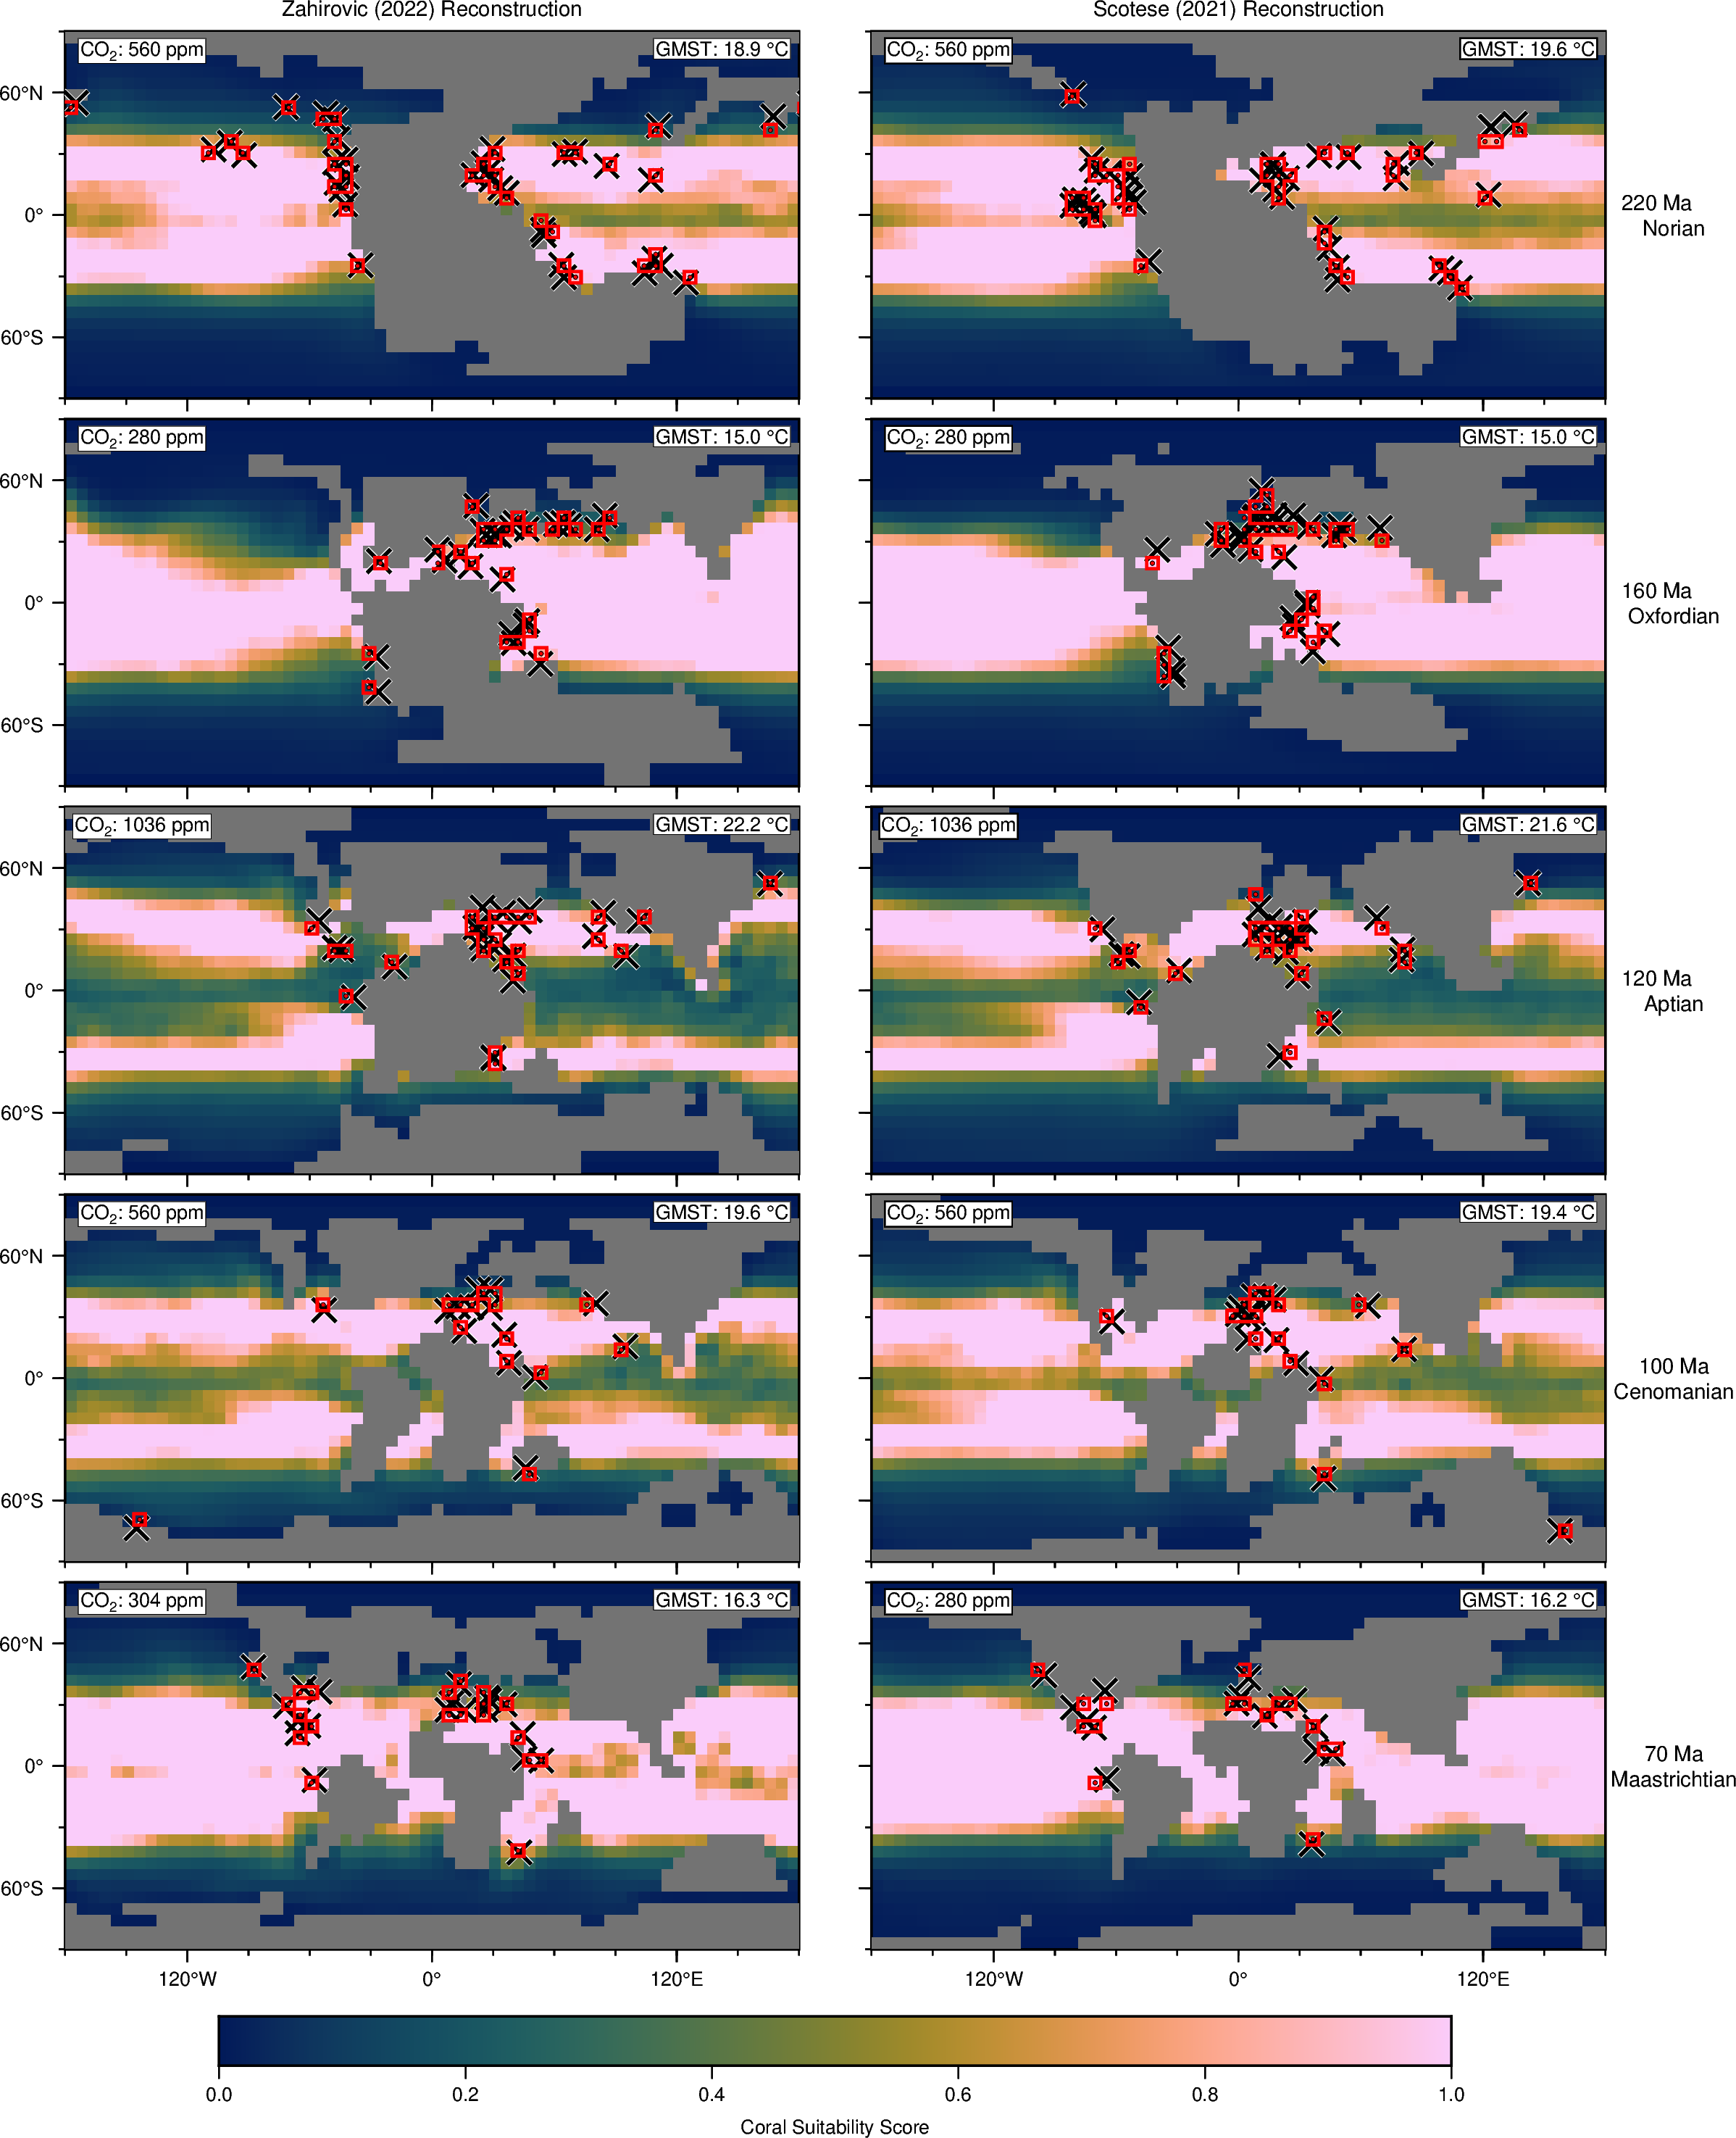

In [211]:
# Figure for a single snapshot
# age = 100
co2_scenario = 'Scotese2021_paleotemps_tropical'
ebyteScenario.fuzzyModelName = f'proj_earthByte_paleomag/{co2_scenario}'
scoteseScenario.fuzzyModelName = f'proj_scotese/{co2_scenario}'
# scoteseScenario.fuzzyModelName = f'proj_earthByte_paleomag/{co2_scenario}'
ebyteTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Paleotopography_earthbyte/topos_filled_PaleomagRef"
scoteseTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Scotese_1deg_renamed"
ebyteScenario.topoPath = ebyteTopoPath
scoteseScenario.topoPath = scoteseTopoPath


figFolder = 'figures/fuzzy_logic_projection_earthByte_paleomag'
if not os.path.exists(figFolder):
    os.makedirs(figFolder)

def fuzzy_logic_projection_plot(fig, age, climateScenarioClass, basicParedData, mergedAges, model_prefix='noModelPrefix', figFolder='figures'):
    proj="Q?" # Cylindrical equidistant projection
    region='d' # d = Global region
    pygmt.makecpt(cmap='batlow', reverse=False, series=[0,1], background=True, output='reefProbFuzzy.cpt')
    pygmt.makecpt(cmap='gray', series=[-10,10], background=False, output='landGray.cpt', reverse=True)

    modelName = climateScenarioClass.fuzzyModelName
    fuzzyProjection = f'data/fuzzy_logic_projection_narrow/{modelName}/{age}Ma.nc'

    age10 = int((age + 5)//10 * 10) # In case we don't use the multiple of 10
    topo = f'{climateScenarioClass.topoPath}/topo_{age10}_filled.nc'

    # Bring in the climate data just to get the landsea mask in the model resolution
    # So we can just choose a random CO2 scenario
    climateData = xr.open_dataset(f'{climateScenarioClass.climate_simulations['1120']}/{age10}Ma_nc_outputs/gold_spn_av_0000003000_00.nc')
    climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)
    climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)
    
    select = basicParedData.selectPoints4MergedAges(age, mergedAges)
    ageName = basicParedData.printClosestGeologicalAge(age, level='Age')
    select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
    select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats


    # select = basicParedData.getNearestModelCellCoordinates(select, 'scotese', climateData)

    # The dataarrays need to be put back into netcdf grids for some reason
    # Remove the FillValue that xarray automaticcaly puts in (stuffs up some of the plotting)
    enc = {"_FillValue": None}
    encoding = {var:enc for var in climateData.coords}
    if os.path.exists('climateData.nc'):
        os.remove('climateData.nc')
    climateData.to_netcdf('climateData.nc',encoding=encoding)

    # The clip2shelves function is used to clip the ensemble data to shallow marine shelves
    # However it also processes the data so best to run the projection data through it even when not clipping
    # Just set dontClip=True if that's the case
    data = clip2shelves(age, fuzzyProjection, topo, dontClip=True, fuzzyLogic=True)

    data['e_mean_shelf'] = xr.where(data['e_mean_shelf']>1200,1200,data['e_mean_shelf']) # To cut off too extreme values
    data['e_mean_shelf'].to_netcdf('tmp.nc')
    # ! gmt grdedit tmp.nc -L+n -Gtmp2.nc

    contours = get_contours(climateData, select[f'{model_prefix}_nearestLons'], select[f'{model_prefix}_nearestLats'], 'landsea')

    fig.grdimage('tmp.nc',projection=proj, region=region, cmap='reefProbFuzzy.cpt',nan_transparent=False, interpolation='b',verbose=True)
    fig.grdimage('climateData.nc?landsea', projection=proj, region=region, cmap='landGray.cpt', nan_transparent='+z0')

    fig.plot(x=select[f'{model_prefix}_lons'], y=select[f'{model_prefix}_lats'], style="x0.4c", pen="1.8p,white", fill="white", region=region)
    fig.plot(x=select[f'{model_prefix}_lons'], y=select[f'{model_prefix}_lats'], style="x0.39c", pen="1.2p,black", fill="black", region=region)
    fig.plot(x=select[f'{model_prefix}_nearestLons'], y=select[f'{model_prefix}_nearestLats'], style="c0.05c", pen="0.01p,black", fill="red", region=region)

    print(f"Number of data points: {len(select[f'{model_prefix}_lons'])}")
    print(f"Number of data points to nearest model cell: {len(select[f'{model_prefix}_nearestLons'])}")

    for contour in contours:
        # print(contour)
        fig.plot(x=contour[0], y=contour[1], pen="1p,red", projection=proj, region=region)
    
    return ageName

def convert_foster(age):
    age = int((age+5)//10 * 10) # round the ages to nearest 10 for the co2 matchj scenarios (as opposed to best match scenario)
    return round(fosterCO2_data.loc[age].values[0])
fig = pygmt.Figure()
nrows = 5 # Number of rows in the subplot
anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
ages =[217.75,158.15,117.2,97.2,69.05]
# ages =[58.8,51.9,32.765,19.5,0]
ages = [int((age+5)//10 * 10) for age in ages] # round the ages to nearest 10 for the co2 matchj scenarios (as opposed to best match scenario)
pygmt.config(MAP_FRAME_TYPE="plain")
with fig.subplot(
    nrows=nrows,
    ncols=2,
    figsize=("18c", f"{nrows*4.5}c"),
    sharex="b",
    sharey="l",
    margins=["0.35c", "0c"], 
    frame=['WSrt','xa120f30','ya60f30'],
):
    with fig.set_panel(panel=0):
        fuzzy_logic_projection_plot(fig, ages[0], ebyteScenario, basicParedData, mergedAges, model_prefix='eByte', figFolder=figFolder)
        age10 = (ages[0]+5)//10 * 10
        fig.text(font='7p', text='Zahirovic (2022) Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
        co2 = ebyte_matchingScenarios[co2_scenario][ages[0]]       
        gmst = ebyte_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[0])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=1):
        fuzzy_logic_projection_plot(fig, ages[0], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        age10 = (ages[0]+5)//10 * 10
        ageName = mergedAges[(mergedAges['Start'] > ages[0]) & (mergedAges['End'] <= ages[0])]['Name'].values[0].split('-')
        fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)
        
        fig.text(font='7p', text='Scotese (2021) Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.60c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.60c/0c",verbose=True, no_clip=True)
        co2 = scotese_matchingScenarios[co2_scenario][ages[0]]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[0])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")      
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
    with fig.set_panel(panel=2):
        fuzzy_logic_projection_plot(fig, ages[1], ebyteScenario, basicParedData, mergedAges, model_prefix='eByte', figFolder=figFolder)
        age10 = (ages[1]+5)//10 * 10
        co2 = ebyte_matchingScenarios[co2_scenario][ages[1]]
        
        gmst = ebyte_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[1])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=3):
        fuzzy_logic_projection_plot(fig, ages[1], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        age10 = (ages[1]+5)//10 * 10
        ageName = mergedAges[(mergedAges['Start'] > ages[1]) & (mergedAges['End'] <= ages[1])]['Name'].values[0].split('-')
        fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)        
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.60c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.60c/0c",verbose=True, no_clip=True)
        co2 = scotese_matchingScenarios[co2_scenario][ages[1]]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[1])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")

        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=4):
        fuzzy_logic_projection_plot(fig, ages[2], ebyteScenario, basicParedData, mergedAges, model_prefix='eByte', figFolder=figFolder)
        age10 = (ages[2]+5)//10 * 10
        co2 = ebyte_matchingScenarios[co2_scenario][ages[2]]
        gmst = ebyte_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[2])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=5):
        fuzzy_logic_projection_plot(fig, ages[2], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        age10 = (ages[2]+5)//10 * 10
        ageName = mergedAges[(mergedAges['Start'] > ages[2]) & (mergedAges['End'] <= ages[2])]['Name'].values[0].split('-')
        fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)        
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.60c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.60c/0c",verbose=True, no_clip=True)
        co2 = scotese_matchingScenarios[co2_scenario][ages[2]]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[2])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=6):
        fuzzy_logic_projection_plot(fig, ages[3], ebyteScenario, basicParedData, mergedAges, model_prefix='eByte', figFolder=figFolder)
        age10 = (ages[3]+5)//10 * 10
        co2 = ebyte_matchingScenarios[co2_scenario][ages[3]]
        gmst = ebyte_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[3])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=7):
        fuzzy_logic_projection_plot(fig, ages[3], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        age10 = (ages[3]+5)//10 * 10
        ageName = mergedAges[(mergedAges['Start'] > ages[3]) & (mergedAges['End'] <= ages[3])]['Name'].values[0].split('-')
        fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)    
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.80c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.80c/0c",verbose=True, no_clip=True)
        co2 = scotese_matchingScenarios[co2_scenario][ages[3]]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[3])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")   
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=8):
        fuzzy_logic_projection_plot(fig, ages[4], ebyteScenario, basicParedData, mergedAges, model_prefix='eByte', figFolder=figFolder)
        age10 = (ages[4]+5)//10 * 10
        co2 = ebyte_matchingScenarios[co2_scenario][ages[4]]
        gmst = ebyte_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[4])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=9):
        fuzzy_logic_projection_plot(fig, ages[4], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        age10 = (ages[4]+5)//10 * 10
        ageName = mergedAges[(mergedAges['Start'] > ages[4]) & (mergedAges['End'] <= ages[4])]['Name'].values[0].split('-')
        fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)        
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.80c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.80c/0c",verbose=True, no_clip=True)
        co2 = scotese_matchingScenarios[co2_scenario][ages[4]]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[4])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")

fig.colorbar(frame='a0.2+lCoral Suitability Score', position="JBC", box=None, cmap='reefProbFuzzy.cpt', verbose=True)
fig.show()
fig.savefig(f'{figFolder}/fuzzy_logic_snapshots_mesozoic_{co2_scenario}.png', dpi=300, transparent=True)




In [212]:
mergedAges[(mergedAges['Start'] > ages[4]) & (mergedAges['End'] <= ages[4])]['Name']

13    Maastrichtian
Name: Name, dtype: object

## Latitudinal reef distribution plot and heat map


In [213]:
# ebyte_matchingScenarios[co2_scenario].loc(ages[0])
co2 = ebyte_matchingScenarios[co2_scenario][ages[0]]
if co2 == 'fosterCO2':
    co2 = fosterCO2_data.loc[ages[0]].values[0]
co2

'560'

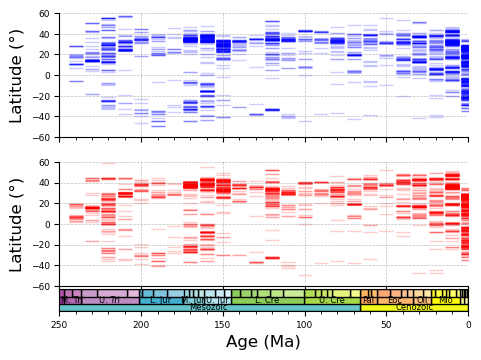

In [214]:
from scipy.interpolate import griddata
fig, axs = plt.subplots(2,1,figsize=(134*mm,90*mm))

axs[0].scatter(basicParedData.df['age10'], basicParedData.df['eByte_lats'], color='blue', alpha=0.2, marker='_', s=100)
axs[1].scatter(basicParedData.df['age10'], basicParedData.df['scotese_lats'], color='red', alpha=0.2, marker='_', s=100)    

axs[0].set_xlim([250,0])
axs[1].set_xlim([250,0])
axs[0].set_xticks(np.arange(0, 251, 50))
# axs[0].set_yticks(np.arange(15, 29.5, 1), minor=True)
axs[0].set_xticks(np.arange(0, 251, 10), minor=True)
# Customize grid appearance
axs[0].xaxis.remove_overlapping_locs = False
axs[0].yaxis.remove_overlapping_locs = False
# axs[0].xaxis.set_visible(False)
# Remove axis tick labels
axs[0].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)

axs[0].set_ylim([-60,60])
axs[1].set_ylim([-60,60])
axs[0].set_ylabel('Latitude (°)')
axs[1].set_ylabel('Latitude (°)')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[0].grid(visible=True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
axs[1].grid(visible=True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
axs[1].tick_params(axis='x', labelbottom=False)

# Add the geolgoical scale under the x axis
# eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# Create a new axis below the main plot, sharing the x-axis
ax0 = fig.add_axes([axs[0].get_position().x0, 0.04, axs[0].get_position().width, 0.06], sharex=axs[0])
ax0.set_xlim(250,0)
ax0.set_ylim(0, 1.5)
ax0.yaxis.set_visible(False)
ax0.set_xlabel('Age (Ma)')
for i, age in geologicalAges.iterrows():
    rect = Rectangle(
        (age['Start'], 0),
        age['End'] - age['Start'],
        1.5,
        facecolor=age['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)


for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (epoch['Start'] + epoch['End']) / 2, 
        0.75, 
        epoch['ShortName'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )


## Shallow marine area percentage

In [215]:
ebyte_geography_path = 'data/paleogeography/topos_filled_PaleomagRef'
scotese_geography_path = 'data/paleogeography/Scotese_1deg_renamed'
import math

ages = np.arange(0,251,10)
ebyte_shelfArea = pd.DataFrame(columns=ages)
scotese_shelfArea = pd.DataFrame(columns=ages)
for age in ages:
# for age in [0]:
    ebyte_age_path = f"{ebyte_geography_path}/topo_{age}_filled.nc"
    scotese_age_path = f"{scotese_geography_path}/topo_{age}_filled.nc"

    ebyte_ds = xr.open_dataset(ebyte_age_path)
    scotese_ds = xr.open_dataset(scotese_age_path)

    areas = {}
    for lat in ebyte_ds['lat'].values:
        if np.abs(lat) > 80:
            continue
        ebyte_lat = ebyte_ds.sel(lat=lat)
        # Get percentage of topos between -300 and 0
        ebyte_topos = ebyte_lat.where((ebyte_lat >= -300) & (ebyte_lat <= 0), drop=True)
        ebyte_fraction = ebyte_topos.count() / ebyte_lat.count()
        ebyte_percentage = ebyte_topos.count() / ebyte_lat.count() * 100
        print(f"eByte Age: {age} Ma, Lat: {lat}, Percentage of shelf (-300 to 0 m): {ebyte_fraction['z'].values}%")
        # Get the area of each latitude band
        lat0 = np.deg2rad(np.abs(lat)-0.25)
        lat1 = np.deg2rad(np.abs(lat)+0.25)
        R = 6378
        area = 2 * math.pi * (R**2) * abs(math.sin(lat1) - math.sin(lat0))
        print(f"eByte Age: {age} Ma, Lat: {lat}, Area of shelf (-300 to 0 m): {area*ebyte_fraction['z'].values} km^2")
        areas[lat] = area*ebyte_fraction['z'].values/100
        # areas[lat] = area
    ebyte_shelfArea[age] = areas

    areas = {}
    for lat in scotese_ds['lat'].values:
        if np.abs(lat) > 80:
            continue
        scotese_elevs = scotese_ds.sel(lat=lat)
        # Get percentage of topos between -300 and 0
        scotese_topos = scotese_elevs.where((scotese_elevs >= -300) & (scotese_elevs <= 0), drop=True)
        scotese_fraction = scotese_topos.count() / scotese_elevs.count()
        scotese_percentage = scotese_topos.count() / scotese_elevs.count() * 100
        print(f"Scotese Age: {age} Ma, Lat: {lat}, Percentage of shelf (-300 to 0 m): {scotese_fraction['z'].values}%")
        # Get the area of each latitude band
        lat0 = np.deg2rad(np.abs(lat)-0.25)
        lat1 = np.deg2rad(np.abs(lat)+0.25)
        R = 6378
        area = 2 * math.pi * (R**2) * abs(math.sin(lat1) - math.sin(lat0))
        print(f"Scotese Age: {age} Ma, Lat: {lat}, Area of shelf (-300 to 0 m): {area*scotese_fraction['z'].values} km^2")
        areas[np.round(lat)] = area*scotese_fraction['z'].values/100 # hectares
        # areas[lat] = area
    scotese_shelfArea[age] = areas


eByte Age: 0 Ma, Lat: -80.0, Percentage of shelf (-300 to 0 m): 0.015256588072122053%
eByte Age: 0 Ma, Lat: -80.0, Area of shelf (-300 to 0 m): 5909.116366381532 km^2
eByte Age: 0 Ma, Lat: -79.5, Percentage of shelf (-300 to 0 m): 0.033287101248266296%
eByte Age: 0 Ma, Lat: -79.5, Area of shelf (-300 to 0 m): 13530.190535283906 km^2
eByte Age: 0 Ma, Lat: -79.0, Percentage of shelf (-300 to 0 m): 0.049930651872399444%
eByte Age: 0 Ma, Lat: -79.0, Area of shelf (-300 to 0 m): 21250.099751287333 km^2
eByte Age: 0 Ma, Lat: -78.5, Percentage of shelf (-300 to 0 m): 0.08321775312066575%
eByte Age: 0 Ma, Lat: -78.5, Area of shelf (-300 to 0 m): 37005.492370461674 km^2
eByte Age: 0 Ma, Lat: -78.0, Percentage of shelf (-300 to 0 m): 0.10263522884882108%
eByte Age: 0 Ma, Lat: -78.0, Area of shelf (-300 to 0 m): 47595.97824306993 km^2
eByte Age: 0 Ma, Lat: -77.5, Percentage of shelf (-300 to 0 m): 0.1262135922330097%
eByte Age: 0 Ma, Lat: -77.5, Area of shelf (-300 to 0 m): 60930.924859740895 km^

In [216]:
scotese_shelfArea

,0,10,20,30,40,50,60,70,80,90,...,160,170,180,190,200,210,220,230,240,250
-80.0,536.448363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-79.0,624.830765,919.562257,200.417415,730.934102,577.673726,813.458920,589.462986,613.041505,624.830765,848.826699,...,129.681857,282.942233,141.471117,0.000000,0.000000,0.000000,117.892597,200.417415,23.578519,188.628155
-78.0,783.603623,757.911701,385.378831,680.835935,706.527857,642.298052,603.760169,552.376325,552.376325,937.755156,...,38.537883,423.916714,295.457104,0.000000,0.000000,0.000000,192.689416,231.227299,12.845961,256.919221
-77.0,653.241220,625.443721,597.646222,694.937468,681.038719,875.621210,625.443721,486.456228,528.152476,722.734967,...,0.000000,444.759979,166.784992,0.000000,0.000000,41.696248,820.026212,166.784992,13.898749,277.974987
-76.0,941.680151,822.101719,478.313728,896.838239,881.890935,762.312503,777.259807,538.102943,493.261032,538.102943,...,29.894608,672.628679,164.420344,59.789216,0.000000,0.000000,687.575983,254.104168,14.947304,283.998776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76.0,2496.199766,2032.833342,2286.937510,1629.256134,1300.415447,2929.671581,1913.254910,1509.677703,1046.311279,807.154415,...,2167.359078,1449.888487,119.578432,239.156864,298.946080,134.525736,851.996327,926.732847,44.841912,747.365199
77.0,2487.876135,1918.027411,2001.419908,1806.837417,1320.381189,3113.319856,1626.153675,1473.267432,1028.507452,861.722460,...,1945.824910,972.912455,138.987494,97.291246,166.784992,208.481240,806.127463,972.912455,13.898749,764.431215
78.0,1849.818389,2081.045688,1849.818389,1849.818389,1400.209753,2299.427026,1284.596104,1079.060727,783.603623,603.760169,...,1644.283013,809.295545,308.303065,128.459610,51.383844,256.919221,1014.830922,912.063234,25.691922,732.219779
79.0,1367.554126,1615.128580,1556.182282,1721.231918,1485.446724,2063.120449,1674.074879,1061.033374,495.148908,589.462986,...,1556.182282,742.723362,259.363714,141.471117,82.524818,117.892597,1013.876335,860.615959,11.789260,660.198544


/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_69284/766126407.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


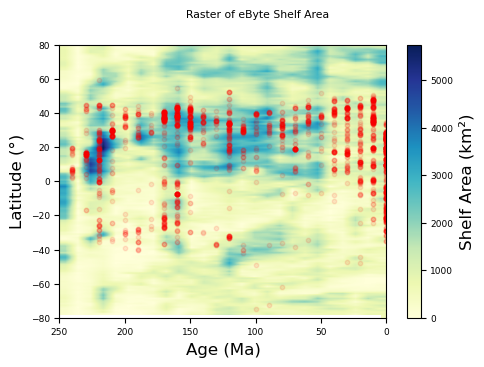

In [217]:
# plot as lat x age raster
# plt.figure(figsize=(10, 6))
fig, ax = plt.subplots(figsize=(134*mm,90*mm))

# Create meshgrid for all age-latitude combinations
ages = scotese_shelfArea.columns
lats = scotese_shelfArea.index

# Create a 2D grid for the raster
Z = np.full((len(lats), len(ages)), np.nan)
for i, lat in enumerate(lats):
    for j, age in enumerate(ages):
        Z[i, j] = scotese_shelfArea.loc[lat, age]

# Create the raster plot
im = ax.imshow(Z, extent=[ages.min(), ages.max(), lats.min(), lats.max()], 
           aspect='auto', origin='lower', cmap='YlGnBu', interpolation='bilinear')

ax.scatter(basicParedData.df['age10'], basicParedData.df['scotese_lats'], color='red', alpha=0.1, marker='o', s=10)

ax.set_xlim([250,0])
fig.colorbar(im, label='Shelf Area (km²)')
fig.suptitle("Raster of eByte Shelf Area")
ax.set_xlabel("Age (Ma)")
ax.set_ylabel("Latitude (°)")
fig.show()

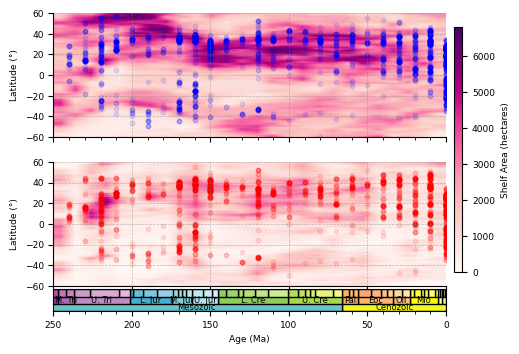

In [218]:
from scipy.interpolate import griddata
fig, axs = plt.subplots(2,1,figsize=(134*mm,90*mm))
# plt.rcParams['font.size']=6.5
# plt.rcParams['pdf.fonttype'] = 42
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['xtick.labelsize'] = 6.5
# plt.rcParams['ytick.labelsize'] = 6.5

# Create meshgrid for all age-latitude combinations
ages = ebyte_shelfArea.columns
lats = ebyte_shelfArea.index
# Create a 2D grid for the raster
Z = np.full((len(lats), len(ages)), np.nan)
for i, lat in enumerate(lats):
    for j, age in enumerate(ages):
        Z[i, j] = ebyte_shelfArea.loc[lat, age]

# Make a normalised cmap to use for both plots
cmap = 'RdPu'
norm = plt.Normalize(vmin=0, vmax=np.nanmax(Z))

# Create the raster plot
im_ebyte = axs[0].imshow(Z, extent=[ages.min(), ages.max(), lats.min(), lats.max()], 
           aspect='auto', origin='lower', cmap=cmap, norm=norm, interpolation='bilinear')

# Create meshgrid for all age-latitude combinations
ages = scotese_shelfArea.columns
lats = scotese_shelfArea.index
# Create a 2D grid for the raster
Z = np.full((len(lats), len(ages)), np.nan)
for i, lat in enumerate(lats):
    for j, age in enumerate(ages):
        Z[i, j] = scotese_shelfArea.loc[lat, age]
# Create the raster plot
im_scotese = axs[1].imshow(Z, extent=[ages.min(), ages.max(), lats.min(), lats.max()], 
           aspect='auto', origin='lower', cmap=cmap, norm=norm, interpolation='bilinear')

axs[0].scatter(basicParedData.df['age10'], basicParedData.df['eByte_lats'], color='blue', alpha=0.1, marker='o', s=10)
axs[1].scatter(basicParedData.df['age10'], basicParedData.df['scotese_lats'], color='red', alpha=0.1, marker='o', s=10)    

axs[0].set_xlim([250,0])
axs[1].set_xlim([250,0])
axs[0].set_xticks(np.arange(0, 251, 50))
# axs[0].set_yticks(np.arange(15, 29.5, 1), minor=True)
axs[0].set_xticks(np.arange(0, 251, 10), minor=True)
# Customize grid appearance
axs[0].xaxis.remove_overlapping_locs = False
axs[0].yaxis.remove_overlapping_locs = False
# axs[0].xaxis.set_visible(False)
# Remove axis tick labels
axs[0].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False, labelsize=6.5)

axs[0].set_ylim([-60,60])
axs[1].set_ylim([-60,60])
axs[0].set_ylabel('Latitude (°)', fontsize='6.5')
axs[1].set_ylabel('Latitude (°)', fontsize='6.5')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[0].grid(visible=True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
axs[1].grid(visible=True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
axs[1].tick_params(axis='x', labelbottom=False)
cbar = fig.colorbar(im_ebyte, ax=axs, orientation='vertical', fraction=0.02, pad=0.02, label='Shelf Area (hectares)', aspect=30)
cbar.ax.tick_params(labelsize=6.5)
cbar.set_label('Shelf Area (hectares)', fontsize=6.5)

# Add the geolgoical scale under the x axis
# eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# Create a new axis below the main plot, sharing the x-axis
ax0 = fig.add_axes([axs[0].get_position().x0, 0.04, axs[0].get_position().width, 0.06], sharex=axs[0])
ax0.set_xlim(250,0)
ax0.set_ylim(0, 1.5)
ax0.yaxis.set_visible(False)
ax0.set_xlabel('Age (Ma)', fontsize='6.5')
for i, age in geologicalAges.iterrows():
    rect = Rectangle(
        (age['Start'], 0),
        age['End'] - age['Start'],
        1.5,
        facecolor=age['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)


for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (epoch['Start'] + epoch['End']) / 2, 
        0.75, 
        epoch['ShortName'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )

fig.savefig(f'figures/shelf_area_distribution.png', dpi=300, transparent=True)


In [219]:
norm(1)

np.float64(0.00014686940815654022)

In [220]:
# # Biomod comparison plot
# def biomod_sample_probabilities(age, climateScenarioClass, basicParedData, model_prefix='noModelPrefix', select=None):
#     # proj="Q?" # Cylindrical equidistant projection
#     # region='d' # d = Global region
#     # pygmt.makecpt(cmap='batlow', reverse=False, series=[0,1200], background=True, output='reefProb.cpt')
#     # pygmt.makecpt(cmap='gray', series=[-10,10], background=False, output='landGray.cpt', reverse=True)
#     modelAges = np.arange(0,260,10)
#     modelName = climateScenarioClass.biomodModelName

#     modelAge = age
#     ensembleProjection = f'photozoan/{modelName}_{modelAge}Ma/{modelName}_{modelAge}Ma_photozoan_ensemble.tif'
#     if not os.path.exists(ensembleProjection):
#         print(f"Ensemble projection file {ensembleProjection} does not exist. Rounding age to nearest model age.")
#         modelAge = int(round(age, -1))  # Round to the nearest 10 Ma
#         if modelAge not in modelAges:
#             raise ValueError(f"Age {modelAge} Ma is not available in the model ages: {modelAges}")
#         ensembleProjection = f'photozoan/{modelName}_{modelAge}Ma/{modelName}_{modelAge}Ma_photozoan_ensemble.tif'

#     topo = f'{climateScenarioClass.topoPath}/topo_{modelAge}_filled.nc'

#     # Bring in the climate data just to get the landsea mask in the model resolution
#     # So we can just choose a random CO2 scenario
#     climateData = xr.open_dataset(f'{climateScenarioClass.climate_simulations['1120']}/{modelAge}Ma_nc_outputs/gold_spn_av_0000003000_00.nc')
#     climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)
#     climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)
#     if select is None:
#         # If no selection is provided, select all points for the given age
#         # select = basicParedData.selectPoints4Ages(age)
#         select = basicParedData.selectPoints4GeologicalAge(age, level='Age')
#         select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
#         select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats
#     else:
#         select = select # Use this if you already ran this function
#         select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
#         select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats

#     # Just set dontClip=True if that's the case
#     data = clip2shelves(modelAge, ensembleProjection, topo, dontClip=True)

#     data['e_mean_shelf'] = xr.where(data['e_mean_shelf']>1200,1200,data['e_mean_shelf']) # To cut off too extreme values
#     netcdfDir = f'{modelName}_biomodMeans'
#     netcdfFile = f'{netcdfDir}/{modelAge}.nc'
#     if not os.path.exists(netcdfDir):
#         os.makedirs(netcdfDir)
#     data['e_mean_shelf'].to_netcdf(netcdfFile)

#     probs = []
#     for i in range(len(select)):
#         # Get the nearest model cell coordinates
#         nearest_lon = select[f'{model_prefix}_nearestLons'][i]
#         nearest_lat = select[f'{model_prefix}_nearestLats'][i]

#         landVal = climateData['landNAN'].sel(longitude=nearest_lon, latitude=nearest_lat, method='nearest').values.item()
#         if landVal != 0.:
#             probs.append(np.nan)
#             continue

#         # Get the model cell value
#         model_value = data['e_mean_shelf'].sel(lon=nearest_lon, lat=nearest_lat, method='nearest').values.item()
#         probs.append(model_value)

#     select[f'{model_prefix}Probability'] = probs
#     return select

# eByte_probs = {}
# scotese_probs = {}
# combinedDF = pd.DataFrame()
# for age in mergedAges['MeanAge'].to_list():   
#     print('\n') 
#     try:  
#         model_prefix='eByte'
#         climateScenarioClass = ebyteScenario
#         probsDF = biomod_sample_probabilities(age, climateScenarioClass, basicParedData, model_prefix=model_prefix)
#         eByte_probs[age] = (np.nanmean(probsDF[f'{model_prefix}Probability']), sem(probsDF[f'{model_prefix}Probability'], nan_policy='omit'), np.sum(~np.isnan(probsDF[f'{model_prefix}Probability'])))
#         model_prefix='scotese'
#         climateScenarioClass = scoteseScenario
#         probsDF = biomod_sample_probabilities(age, climateScenarioClass, basicParedData, model_prefix=model_prefix, select=probsDF)
#         scotese_probs[age] = (np.nanmean(probsDF[f'{model_prefix}Probability']), sem(probsDF[f'{model_prefix}Probability'], nan_policy='omit'), np.sum(~np.isnan(probsDF[f'{model_prefix}Probability'])))
#         combinedDF = pd.concat([combinedDF, probsDF], ignore_index=True)
#     except Exception as e:
#         print(f"Error processing age {age}: {e}")
#         continue

# combinedDF['epoch'] = combinedDF['age'].apply(lambda age: basicParedData.printClosestGeologicalAge(age, level='Epoch'))
# combinedDF['geoAge'] = combinedDF['age'].apply(lambda age: basicParedData.printClosestGeologicalAge(age, level='Age'))

In [221]:
# # Biomod comparison plot
# from matplotlib.patches import Rectangle

# mm = 1/25.4  # mm in inches
# fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# # Set Y-axis limits
# ax.set_ylim(0, 1000)
# ax.set_xlim(255,-3.2)

# # Add tick marks for the Y-axis
# ax.set_yticks(np.arange(0, 1010, 100))
# ax.set_xticks(np.arange(0, 251, 50))

# # ax.set_yticks(np.arange(15, 29.5, 1), minor=True)
# ax.set_xticks(np.arange(0, 251, 10), minor=True)

# # Customize grid appearance
# ax.xaxis.remove_overlapping_locs = False
# ax.yaxis.remove_overlapping_locs = False

# # Remove probs with sizes less than 10
# eByte_probs = {k: v for k, v in eByte_probs.items() if v[2] >= 5}
# scotese_probs = {k: v for k, v in scotese_probs.items() if v[2] >= 5}

# ax.plot(eByte_probs.keys(), list(zip(*eByte_probs.values()))[0], linewidth=1.2, color='blue', label='Paleogeography Model #1 (Cao2017)')
# ax.errorbar(eByte_probs.keys(), list(zip(*eByte_probs.values()))[0], yerr=list(zip(*eByte_probs.values()))[1], linewidth=1.2, color='blue', elinewidth=1, markeredgewidth=1)

# ax.plot(scotese_probs.keys(), list(zip(*scotese_probs.values()))[0], linewidth=1.2, color='red', label='Paleogeography Model #2 (Scotese2021)')
# ax.errorbar(scotese_probs.keys(), list(zip(*scotese_probs.values()))[0], yerr=list(zip(*scotese_probs.values()))[1], linewidth=1.2, color='red', elinewidth=1, markeredgewidth=1)

# # ax.set_xlabel('Age (Ma)')
# ax.set_ylabel('Average Reef Suitability')
# ax.xaxis.set_visible(False)

# # Secondary axis
# ax2 = ax.twinx()
# ax2.set_ylim(0, 200)
# ax2.set_yticks(np.arange(0, 61, 10))
# ax2.set_ylabel('No. of Unique Reef Localities')
# # Histogram with epoch bins
# # uniqueEpochs = combinedDF.groupby('epoch')
# # countsEbyte = {}
# # countsScotese = {}
# # for epoch, group in uniqueEpochs:
# #     countsEbyte[epoch] = group[group['eByteProbability'].notna()]['eByteProbability'].count()
# #     countsScotese[epoch] = group[group['scoteseProbability'].notna()]['scoteseProbability'].count()

# epochBins = [0] + epochs['Start'].tolist()
# ageBins = [0] + mergedAges['Start'].tolist()
# # Plot histograms for the two models using the 'age' column, filtering for non-null probabilities
# ax2.hist(combinedDF.loc[combinedDF['eByteProbability'].notna(), 'age'], bins=ageBins, color='blue', alpha=0.5, label='Paleogeography Model #1 (Cao2017)')
# ax2.hist(combinedDF.loc[combinedDF['scoteseProbability'].notna(), 'age'], bins=ageBins, color='red', alpha=0.5, label='Paleogeography Model #2 (Scotese2021)')

# ax2.plot([], [], color='black', linestyle=':', label='No. of Unique Reef Localities')

# ax.legend(loc='upper right', ncol=1, frameon=False)
# # ax2.legend(loc='lower center', ncol=1, frameon=False)

# # Hide the right and top spines
# ax.spines[['top']].set_visible(False)
# ax2.spines[['top']].set_visible(False)

# # Add the geolgoical scale under the x axis
# # eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# # Create a new axis below the main plot, sharing the x-axis
# ax0 = fig.add_axes([ax.get_position().x0, 0.04, ax.get_position().width, 0.06], sharex=ax)
# ax0.set_xlim(250,0)
# ax0.set_ylim(0, 1)
# ax0.yaxis.set_visible(False)
# ax0.set_xlabel('Age (Ma)')
# for i, epoch in epochs.iterrows():
#     rect = Rectangle(
#         (epoch['Start'], 0),
#         epoch['End'] - epoch['Start'],
#         1,
#         facecolor=epoch['Color'],
#         edgecolor='k',
#         alpha=1
#     )
#     ax0.add_artist(rect)
#     ax0.text(
#         (epoch['Start'] + epoch['End']) / 2, 
#         0.75, 
#         epoch['ShortName'], 
#         ha='center', 
#         va='center', 
#         fontsize=6, 
#         rotation=0
#     )
# # Add the era names underneath the epochs
# for i, era in eras.iterrows():
#     rect = Rectangle(
#         (era['Start'], 0),
#         era['End'] - era['Start'],
#         0.5,
#         facecolor=era['Color'],
#         edgecolor='k',
#         alpha=1
#     )
#     ax0.add_artist(rect)
#     ax0.text(
#         (era['Start'] + era['End']) / 2, 
#         0.25, 
#         era['Name'], 
#         ha='center', 
#         va='center', 
#         fontsize=6, 
#         rotation=0
#     )

## Comparison plots - Fuzzy Logic


In [222]:
def fuzzyLogic_sample_probabilities(age, climateScenarioClass, basicParedData, mergedAges, model_prefix='noModelPrefix', select=None, prescribeCO2=False):
    # proj="Q?" # Cylindrical equidistant projection
    # region='d' # d = Global region
    # pygmt.makecpt(cmap='batlow', reverse=False, series=[0,1200], background=True, output='reefProb.cpt')
    # pygmt.makecpt(cmap='gray', series=[-10,10], background=False, output='landGray.cpt', reverse=True)
    modelAges = np.arange(0,260,10)
    # This chunk of code is a frankenstein, I hate it but oh well
    modelName = climateScenarioClass.fuzzyModelName
    if prescribeCO2:
        baseModelName = modelName.split('/')[0]  # Get the base model name without the CO2 scenario
        modelName = f'{baseModelName}/{prescribeCO2}ppm'

    modelAge = age
    print('\n')
    print(f"Processing fuzzy logic probabilities for {modelName} at {age} Ma")
    fuzzyProjection = f'data/fuzzy_logic_projection_narrow/{modelName}/{modelAge}Ma.nc'

    if not os.path.exists(fuzzyProjection):
        print(f"Fuzzy logic projection file {fuzzyProjection} does not exist.")
        # If the age is not available in the model, round it to the
        modelAge = int(round(age, -1))  # Round to the nearest 10 Ma
        if modelAge not in modelAges:
            raise ValueError(f"Age {modelAge} Ma is not available in the model ages: {modelAges}")
        print(f"Processing fuzzy logic probabilities for {modelName} at {modelAge} Ma (rounded)")
        fuzzyProjection = f'data/fuzzy_logic_projection_narrow/{modelName}/{modelAge}Ma.nc'

    topo = f'{climateScenarioClass.topoPath}/topo_{modelAge}_filled.nc'

    # Bring in the climate data just to get the landsea mask in the model resolution
    # So we can just choose a random CO2 scenario
    climateData = xr.open_dataset(f'{climateScenarioClass.climate_simulations['1120']}/{modelAge}Ma_nc_outputs/gold_spn_av_0000003000_00.nc')
    climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)
    climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)
    if select is None:
        # If no selection is provided, select all points for the given age
        # select = basicParedData.selectPoints4Ages(age)
        select = basicParedData.selectPoints4MergedAges(age, mergedAges)
        select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
        select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats
    else:
        select = select # Use this if you already ran this function
        select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
        select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats

    if not os.path.exists(fuzzyProjection):
        select[f'{model_prefix}Probability'] = np.nan
        print(f"Fuzzy logic projection file {fuzzyProjection} does not exist. Returning NaN probabilities.")
        return select
    # Just set dontClip=True if that's the case
    data = clip2shelves(modelAge, fuzzyProjection, topo, dontClip=True, fuzzyLogic=True)

    data['e_mean_shelf'] = xr.where(data['e_mean_shelf']>1200,1200,data['e_mean_shelf']) # To cut off too extreme values
    # data['e_mean_shelf'].to_netcdf('tmp.nc')
    netcdfDir = f'{modelName}_fuzzyLogicMeans'
    netcdfFile = f'{netcdfDir}/{modelAge}.nc'
    if not os.path.exists(netcdfDir):
        os.makedirs(netcdfDir)
    data['e_mean_shelf'].to_netcdf(netcdfFile)
    # data['e_mean_shelf'].to_netcdf('test.nc')

    probs = []
    for i in range(len(select)):
        # Get the nearest model cell coordinates
        nearest_lon = select[f'{model_prefix}_nearestLons'][i]
        nearest_lat = select[f'{model_prefix}_nearestLats'][i]
        landVal = climateData['landNAN'].sel(longitude=nearest_lon, latitude=nearest_lat, method='nearest').values.item()
        if landVal != 0.:
            probs.append(np.nan)
            continue

        # Get the model cell value
        model_value = data['e_mean_shelf'].sel(lon=nearest_lon, lat=nearest_lat, method='nearest').values.item()
        print(f"Model value for point {i+1}: {model_value}")
        probs.append(model_value)

    select[f'{model_prefix}Probability'] = probs
    return select


In [223]:

eByte_probs = {}
scotese_probs = {}
combinedDF = pd.DataFrame()
ages2plot = mergedAges['MeanAge'].to_list()
ages2plot = [age for age in ages2plot if age <= 253]  # Filter out negative ages
for age in ages2plot:   
    print('\n')
    try:  
        model_prefix='eByte'
        climateScenarioClass = ebyteScenario
        probsDF = fuzzyLogic_sample_probabilities(age, climateScenarioClass, basicParedData, mergedAges, model_prefix=model_prefix)
        eByte_probs[age] = (np.nanmean(probsDF[f'{model_prefix}Probability']), stats.sem(probsDF[f'{model_prefix}Probability'], nan_policy='omit'), np.sum(~np.isnan(probsDF[f'{model_prefix}Probability'])))

        model_prefix='scotese'
        climateScenarioClass = scoteseScenario
        probsDF = fuzzyLogic_sample_probabilities(age, climateScenarioClass, basicParedData, mergedAges, model_prefix=model_prefix, select=probsDF)
        scotese_probs[age] = (np.nanmean(probsDF[f'{model_prefix}Probability']), stats.sem(probsDF[f'{model_prefix}Probability'], nan_policy='omit'), np.sum(~np.isnan(probsDF[f'{model_prefix}Probability'])))
        combinedDF = pd.concat([combinedDF, probsDF], ignore_index=True)
    except Exception as e:
        print(f"Error processing age {age}: {e}")
        continue

combinedDF['epoch'] = combinedDF['age'].apply(lambda age: basicParedData.printClosestGeologicalAge(age, level='Epoch'))
combinedDF['geoAge'] = combinedDF['age'].apply(lambda age: basicParedData.printClosestGeologicalAge(age, level='Age'))





Processing fuzzy logic probabilities for proj_earthByte_paleomag/Scotese2021_paleotemps_tropical at 0.0041 Ma
Fuzzy logic projection file data/fuzzy_logic_projection_narrow/proj_earthByte_paleomag/Scotese2021_paleotemps_tropical/0.0041Ma.nc does not exist.
Processing fuzzy logic probabilities for proj_earthByte_paleomag/Scotese2021_paleotemps_tropical at 0 Ma (rounded)
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.6741216]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 149.1
  * latitude   (latitude) float32 4B -2.77
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.6473863]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 149.1
  * latitude   (latitude) float32 4B -2.77
No valid subset found at 36.5625, 30.470705032348633
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.6125093]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 149.1
  * latitude   (latitude) float32 4B -

In [224]:
# probsDF[f'{model_prefix}Probability'].sem()
import scipy.stats as stats
stats.sem(probsDF[f'{model_prefix}Probability'], nan_policy='omit')

np.float64(0.024215500428525934)

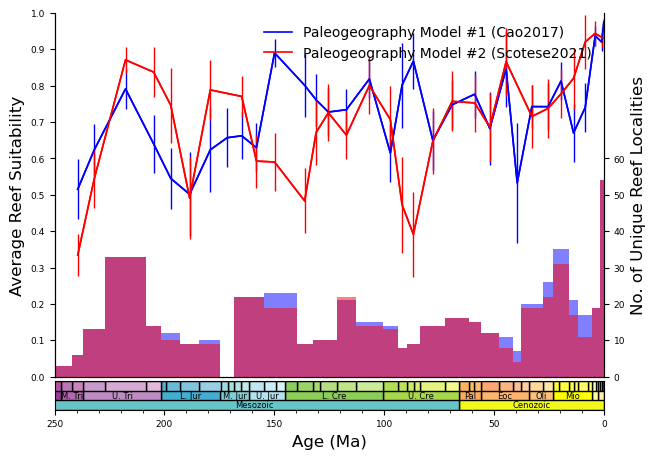

In [225]:
mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(0, 1)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(np.arange(0, 251, 50))

# ax.set_yticks(np.arange(15, 29.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

# Remove probs with sizes less than 10
eByte_probs = {k: v for k, v in eByte_probs.items() if v[2] >= 5}
scotese_probs = {k: v for k, v in scotese_probs.items() if v[2] >= 5}

ax.plot(eByte_probs.keys(), list(zip(*eByte_probs.values()))[0], linewidth=1.2, color='blue', label='Paleogeography Model #1 (Cao2017)')
ax.errorbar(eByte_probs.keys(), list(zip(*eByte_probs.values()))[0], yerr=list(zip(*eByte_probs.values()))[1], linewidth=1.2, color='blue', elinewidth=1, markeredgewidth=1)

ax.plot(scotese_probs.keys(), list(zip(*scotese_probs.values()))[0], linewidth=1.2, color='red', label='Paleogeography Model #2 (Scotese2021)')
ax.errorbar(scotese_probs.keys(), list(zip(*scotese_probs.values()))[0], yerr=list(zip(*scotese_probs.values()))[1], linewidth=1.2, color='red', elinewidth=1, markeredgewidth=1)

# ax.set_xlabel('Age (Ma)')
ax.set_ylabel('Average Reef Suitability')
ax.xaxis.set_visible(False)

# Secondary axis
ax2 = ax.twinx()
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 61, 10))
ax2.set_ylabel('No. of Unique Reef Localities')

epochBins = [0] + epochs['Start'].tolist()
ageBins = [0] + mergedAges['Start'].tolist()
# Plot histograms for the two models using the 'age' column, filtering for non-null probabilities
ax2.hist(combinedDF.loc[combinedDF['eByteProbability'].notna(), 'age'], bins=ageBins, color='blue', alpha=0.5, label='Paleogeography Model #1 (Cao2017)')
ax2.hist(combinedDF.loc[combinedDF['scoteseProbability'].notna(), 'age'], bins=ageBins, color='red', alpha=0.5, label='Paleogeography Model #2 (PALEOMAP)')

ax2.plot([], [], color='black', linestyle=':', label='No. of Unique Reef Localities')

ax.legend(loc='upper right', ncol=1, frameon=False)
# ax2.legend(loc='lower center', ncol=1, frameon=False)

# Hide the right and top spines
ax.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

# Add the geolgoical scale under the x axis
# eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# Create a new axis below the main plot, sharing the x-axis
ax0 = fig.add_axes([ax.get_position().x0, 0.04, ax.get_position().width, 0.06], sharex=ax)
ax0.set_xlim(250,0)
ax0.set_ylim(0, 1.5)
ax0.yaxis.set_visible(False)
ax0.set_xlabel('Age (Ma)')
for i, age in geologicalAges.iterrows():
    rect = Rectangle(
        (age['Start'], 0),
        age['End'] - age['Start'],
        1.5,
        facecolor=age['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)


for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (epoch['Start'] + epoch['End']) / 2, 
        0.75, 
        epoch['ShortName'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
fig.savefig(f'{figFolder}/fuzzy_logic_probabilities_{co2_scenario}.png', dpi=300, transparent=True)

# Best match

In [398]:
ebyte_CO2s = pd.DataFrame(index=mergedAges['MeanAge'].to_list())
ebyte_CO2s_sems = pd.DataFrame(index=mergedAges['MeanAge'].to_list())
scotese_CO2s = pd.DataFrame(index=mergedAges['MeanAge'].to_list())
scotese_CO2s_sems = pd.DataFrame(index=mergedAges['MeanAge'].to_list())
for co2 in co2s:
    aveProbsEbyte = {}
    semsProbsEbyte = {}
    aveProbsScotese = {}
    semsProbsScotese = {}
    for age in mergedAges['MeanAge'].to_list(): 
    # for age in np.arange(150, 160, 10):
        if age > 253:
            continue
        model_prefix='eByte'
        climateScenarioClass = ebyteScenario
        try:
            probsDF = fuzzyLogic_sample_probabilities(age, climateScenarioClass, basicParedData, mergedAges, model_prefix=model_prefix, prescribeCO2=co2)
            if len(probsDF) < 4:
                continue
            aveProbsEbyte[age] = probsDF[f'{model_prefix}Probability'].mean()
            semsProbsEbyte[age] = probsDF[f'{model_prefix}Probability'].sem()
        except Exception as e:
            print(f"Error processing age {age} for {model_prefix} with CO2 {co2}: {e}")
            aveProbsEbyte[age] = np.nan
            # continue
        # allCO2s[f'{model_prefix}_' + str(co2)] = probsDF[f'{model_prefix}Probability']
        sys.exit()

        model_prefix='scotese'
        climateScenarioClass = scoteseScenario
        try:
            probsDF = fuzzyLogic_sample_probabilities(age, climateScenarioClass, basicParedData, mergedAges, model_prefix=model_prefix, prescribeCO2=co2)
            aveProbsScotese[age] = probsDF[f'{model_prefix}Probability'].mean()
            semsProbsScotese[age] = probsDF[f'{model_prefix}Probability'].sem()
        except Exception as e:
            print(f"Error processing age {age} for {model_prefix} with CO2 {co2}: {e}")
            aveProbsScotese[age] = np.nan


    ebyte_CO2s[f'eByte_{co2}'] = pd.Series(aveProbsEbyte)
    ebyte_CO2s_sems[f'eByte_{co2}'] = pd.Series(semsProbsEbyte)
    scotese_CO2s[f'scotese_{co2}'] = pd.Series(aveProbsScotese)
    scotese_CO2s_sems[f'scotese_{co2}'] = pd.Series(semsProbsScotese)



Processing fuzzy logic probabilities for proj_earthByte_paleomag/100ppm at 0.0041 Ma
Fuzzy logic projection file data/fuzzy_logic_projection_narrow/proj_earthByte_paleomag/100ppm/0.0041Ma.nc does not exist.
Processing fuzzy logic probabilities for proj_earthByte_paleomag/100ppm at 0 Ma (rounded)
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.6741216]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 149.1
  * latitude   (latitude) float32 4B -2.77
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.6473863]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 149.1
  * latitude   (latitude) float32 4B -2.77
No valid subset found at 36.5625, 30.470705032348633
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.6125093]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 149.1
  * latitude   (latitude) float32 4B -13.85
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.35421

SystemExit: 

/Users/jono/opt/anaconda3/envs/paleoreef/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
scotese_CO2s.head(60)

,scotese_100,scotese_200,scotese_280,scotese_560,scotese_1120,scotese_2240,scotese_4480,scotese_fosterCO2
0.0041,NaN,0.890749,0.931132,NaN,0.832215,0.623511,NaN,NaN
0.0686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.9645,NaN,0.892056,0.933704,NaN,0.762183,0.567329,NaN,NaN
3.9565,NaN,0.851745,0.923904,NaN,0.690725,0.525728,NaN,NaN
8.4815,NaN,0.886638,0.930083,0.767468,0.514814,0.325980,0.194753,0.926655
13.8000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19.5000,NaN,0.760491,0.785376,0.721336,0.526805,0.390505,0.320912,0.784450
25.4250,NaN,0.699346,0.759229,0.804154,0.676627,0.487322,0.336743,0.783648
32.7650,NaN,0.670877,0.715136,0.772809,0.656933,0.500479,0.320174,0.745430
39.4550,NaN,0.574406,0.600437,0.571056,0.507174,0.473280,0.497821,0.577410


In [229]:
optimalCO2s_ebyte = {}
for age in ebyte_CO2s.index:
    row = ebyte_CO2s.loc[age]
    max = row.idxmax()
    maxProb = row.max()

    # If the difference between the max probability and the adjacent probabilities is less than the standard error, then choose the probability of the higher co2/index
    if maxProb > 0:
        # maxDiff = ebyte_CO2s.loc[age][max] - ebyte_CO2s.loc[age].drop(max).max()
        maxIndex = ebyte_CO2s.columns.get_loc(max)
        # sys.exit()
        # maxDiff = row.iloc[maxIndex] - row.iloc[maxIndex + 1]
        semMaxProb = ebyte_CO2s_sems.loc[age][max]
        minRange = maxProb - semMaxProb
        maxRange = maxProb + semMaxProb

        print(f'The range of uncertainty for {age}Ma is {minRange:.2f} to {maxRange:.2f}. The maximum probability is {maxProb:.2f} with an sem of {semMaxProb:.2f}.')

        # Choose columns that sit within the min and max ranges
        selected_columns = ebyte_CO2s.loc[age][(ebyte_CO2s.loc[age] >= minRange) & (ebyte_CO2s.loc[age] <= maxRange)].index
        age10 = (age + 5)//10 * 10
        maxGMST = ebyte_modelGMST_df[max.split('_')[1]][age10]
        maxSST = ebyte_modelSST_df[max.split('_')[1]][age10]
        maxSongSST = ebyte_songSST_df[max.split('_')[1]][age10]
        maxTropicalAir = ebyte_model_tropicalAirTemp[max.split('_')[1]][age10]
        GMSTs = []
        SSTs = []
        songSSTs = []
        tropicalAirTemps = []
        for col in selected_columns:
            GMST = ebyte_modelGMST_df[col.split('_')[1]][age10]
            SST = ebyte_modelSST_df[col.split('_')[1]][age10]
            songSST = ebyte_songSST_df[col.split('_')[1]][age10]
            tropicalAir = ebyte_model_tropicalAirTemp[col.split('_')[1]][age10]
            GMSTs.append(GMST)
            SSTs.append(SST)
            songSSTs.append(songSST)
            tropicalAirTemps.append(tropicalAir)

        optimalCO2s_ebyte[age] = (selected_columns.tolist(), maxProb, maxGMST, GMSTs, maxSST, SSTs, maxSongSST, songSSTs, maxTropicalAir, tropicalAirTemps, semMaxProb)
        print('\n')
GMSTS_ebyte = list(zip(*optimalCO2s_ebyte.values()))[3]
GMSTS_max_ebyte = [np.max(gmsts) for gmsts in GMSTS_ebyte]
GMSTS_min_ebyte = [np.min(gmsts) for gmsts in GMSTS_ebyte]

SSTs_ebyte = list(zip(*optimalCO2s_ebyte.values()))[5]
SSTs_max_ebyte = [np.max(ssts) for ssts in SSTs_ebyte]
SSTs_min_ebyte = [np.min(ssts) for ssts in SSTs_ebyte]

songSSTs_ebyte = list(zip(*optimalCO2s_ebyte.values()))[7]
songSSTs_max_ebyte = [np.max(songSSTs) for songSSTs in songSSTs_ebyte]
songSSTs_min_ebyte = [np.min(songSSTs) for songSSTs in songSSTs_ebyte]

tropicalAirTemps_ebyte = list(zip(*optimalCO2s_ebyte.values()))[9]
tropicalAirTemps_max_ebyte = [np.max(tropicalAirTemps) for tropicalAirTemps in tropicalAirTemps_ebyte]
tropicalAirTemps_min_ebyte = [np.min(tropicalAirTemps) for tropicalAirTemps in tropicalAirTemps_ebyte]

optimalCO2s_scotese = {}
for age in scotese_CO2s.index:
    row = scotese_CO2s.loc[age]
    max = row.idxmax()
    maxProb = row.max()

    # If the difference between the max probability and the adjacent probabilities is less than the standard error, then choose the probability of the higher co2/index
    if maxProb > 0:
        # maxDiff = scotese_CO2s.loc[age][max] - scotese_CO2s.loc[age].drop(max).max()
        maxIndex = scotese_CO2s.columns.get_loc(max)
        # sys.exit()
        # maxDiff = row.iloc[maxIndex] - row.iloc[maxIndex + 1]
        semMaxProb = scotese_CO2s_sems.loc[age][max]
        minRange = maxProb - semMaxProb
        maxRange = maxProb + semMaxProb

        print(f'The range of uncertainty for {age}Ma is {minRange:.2f} to {maxRange:.2f}. The maximum probability is {maxProb:.2f} with an sem of {semMaxProb:.2f}.')

        # Choose columns that sit within the min and max ranges
        selected_columns = scotese_CO2s.loc[age][(scotese_CO2s.loc[age] >= minRange) & (scotese_CO2s.loc[age] <= maxRange)].index
        age10 = (age + 5)//10 * 10
        maxGMST = scotese_modelGMST_df[max.split('_')[1]][age10]
        maxSST = scotese_modelSST_df[max.split('_')[1]][age10]
        maxSongSST = scotese_songSST_df[max.split('_')[1]][age10]
        maxTropicalAir = scotese_model_tropicalAirTemp[max.split('_')[1]][age10]
        GMSTs = []
        SSTs = []
        songSSTs = []
        tropicalAirTemps = []
        for col in selected_columns:
            GMST = scotese_modelGMST_df[col.split('_')[1]][age10]
            GMSTs.append(GMST)
            SST = scotese_modelSST_df[col.split('_')[1]][age10]
            SSTs.append(SST)
            songSST = scotese_songSST_df[col.split('_')[1]][age10]
            songSSTs.append(songSST)
            tropicalAir = scotese_model_tropicalAirTemp[col.split('_')[1]][age10]
            tropicalAirTemps.append(tropicalAir)

        optimalCO2s_scotese[age] = (selected_columns.tolist(), maxProb, maxGMST, GMSTs, maxSST, SSTs, maxSongSST, songSSTs, maxTropicalAir, tropicalAirTemps, semMaxProb)
        print('\n')

GMSTS_scotese = list(zip(*optimalCO2s_scotese.values()))[3]
GMSTS_max_scotese = [np.max(gmsts) for gmsts in GMSTS_scotese]
GMSTS_min_scotese = [np.min(gmsts) for gmsts in GMSTS_scotese]

SSTs_scotese = list(zip(*optimalCO2s_scotese.values()))[5]
SSTs_max_scotese = [np.max(ssts) for ssts in SSTs_scotese]
SSTs_min_scotese = [np.min(ssts) for ssts in SSTs_scotese]

songSSTs_scotese = list(zip(*optimalCO2s_scotese.values()))[7]
songSSTs_max_scotese = [np.max(songSSTs) for songSSTs in songSSTs_scotese]
songSSTs_min_scotese = [np.min(songSSTs) for songSSTs in songSSTs_scotese]

tropicalAirTemps_scotese = list(zip(*optimalCO2s_scotese.values()))[9]
tropicalAirTemps_max_scotese = [np.max(tropicalAirTemps) for tropicalAirTemps in tropicalAirTemps_scotese]
tropicalAirTemps_min_scotese = [np.min(tropicalAirTemps) for tropicalAirTemps in tropicalAirTemps_scotese]


The range of uncertainty for 0.0041Ma is 0.97 to 0.99. The maximum probability is 0.98 with an sem of 0.01.


The range of uncertainty for 0.9645Ma is 0.89 to 0.94. The maximum probability is 0.92 with an sem of 0.03.


The range of uncertainty for 3.9565Ma is 0.91 to 0.96. The maximum probability is 0.94 with an sem of 0.03.


The range of uncertainty for 8.4815Ma is 0.77 to 0.87. The maximum probability is 0.82 with an sem of 0.05.


The range of uncertainty for 13.8Ma is 0.59 to 0.75. The maximum probability is 0.67 with an sem of 0.08.


The range of uncertainty for 19.5Ma is 0.77 to 0.87. The maximum probability is 0.82 with an sem of 0.05.


The range of uncertainty for 25.425Ma is 0.68 to 0.81. The maximum probability is 0.74 with an sem of 0.06.


The range of uncertainty for 32.765Ma is 0.76 to 0.87. The maximum probability is 0.81 with an sem of 0.05.


The range of uncertainty for 39.455Ma is 0.37 to 0.70. The maximum probability is 0.53 with an sem of 0.16.


The range of u

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_69284/3683276504.py:4: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max = row.idxmax()
/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_69284/3683276504.py:4: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max = row.idxmax()
/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_69284/3683276504.py:4: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max = row.idxmax()
/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_69284/3683276504.py:4: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise 

In [230]:
eByte_probs

{0.0041: (np.float64(0.9762438523326566),
  np.float64(0.010353022070724388),
  np.int64(43)),
 0.9645: (np.float64(0.9197156904235618),
  np.float64(0.025049516521421598),
  np.int64(55)),
 3.9565: (np.float64(0.9367996349452492),
  np.float64(0.027966460337447156),
  np.int64(20)),
 8.4815: (np.float64(0.7401405708359018),
  np.float64(0.06830655852194994),
  np.int64(21)),
 13.8: (np.float64(0.6697540202189919),
  np.float64(0.08004764221413693),
  np.int64(23)),
 19.5: (np.float64(0.8124321574828983),
  np.float64(0.05154949716201864),
  np.int64(40)),
 25.425: (np.float64(0.7420803325383056),
  np.float64(0.06484919606489109),
  np.int64(30)),
 32.765: (np.float64(0.7424019959759882),
  np.float64(0.06001784537302606),
  np.int64(26)),
 39.455: (np.float64(0.5327042749818738),
  np.float64(0.16498091684200597),
  np.int64(8)),
 44.5: (np.float64(0.8460470726584727),
  np.float64(0.1035240213615367),
  np.int64(11)),
 51.9: (np.float64(0.6821289635593121),
  np.float64(0.0990226622

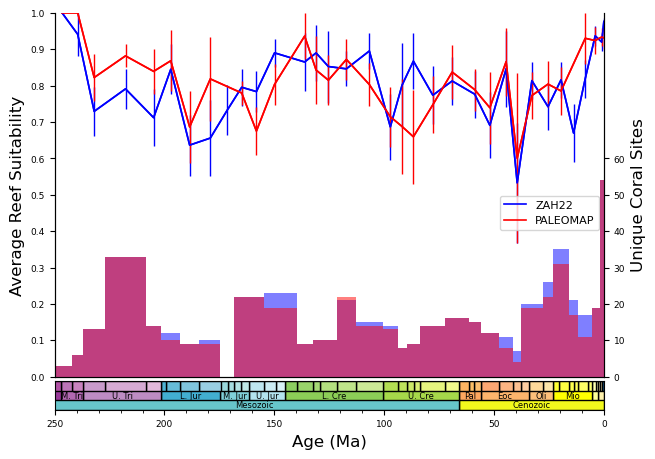

In [231]:
mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(0, 1)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(np.arange(0, 251, 50))

# ax.set_yticks(np.arange(15, 29.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

# Remove probs with sizes less than 10
eByte_probs = {k: v for k, v in eByte_probs.items() if v[2] >= 5}
scotese_probs = {k: v for k, v in scotese_probs.items() if v[2] >= 5}

ax.plot(optimalCO2s_ebyte.keys(), list(zip(*optimalCO2s_ebyte.values()))[1], linewidth=1.2, color='blue', label='ZAH22')
ax.errorbar(optimalCO2s_ebyte.keys(), list(zip(*optimalCO2s_ebyte.values()))[1], yerr=list(zip(*optimalCO2s_ebyte.values()))[-1], linewidth=1.2, color='blue', elinewidth=1, markeredgewidth=1)

ax.plot(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[1], linewidth=1.2, color='red', label='PALEOMAP')
ax.errorbar(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[1], yerr=list(zip(*optimalCO2s_scotese.values()))[-1], linewidth=1.2, color='red', elinewidth=1, markeredgewidth=1)

# ax.set_xlabel('Age (Ma)')
ax.set_ylabel('Average Reef Suitability')
ax.xaxis.set_visible(False)

# Secondary axis
ax2 = ax.twinx()
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 61, 10))
ax2.set_ylabel('Unique Coral Sites')

epochBins = [0] + epochs['Start'].tolist()
ageBins = [0] + mergedAges['Start'].tolist()
# Plot histograms for the two models using the 'age' column, filtering for non-null probabilities
ax2.hist(combinedDF.loc[combinedDF['eByteProbability'].notna(), 'age'], bins=ageBins, color='blue', alpha=0.5, label='ZAH22')
ax2.hist(combinedDF.loc[combinedDF['scoteseProbability'].notna(), 'age'], bins=ageBins, color='red', alpha=0.5, label='PALEOMAP')

ax2.plot([], [], color='black', linestyle=':')

# fig.legend(loc='center left', ncol=1, frameon=False, bbox_to_anchor=(0.91, 0.5))
ax.legend(loc='center left', ncol=1, frameon=True, facecolor='white', bbox_to_anchor=(0.8, 0.45), fontsize=8)
# ax2.legend(loc='center left', ncol=1, frameon=False, bbox_to_anchor=(0, 0.5), fontsize=8)

# Hide the right and top spines
ax.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

# Add the geolgoical scale under the x axis
# eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# Create a new axis below the main plot, sharing the x-axis
ax0 = fig.add_axes([ax.get_position().x0, 0.04, ax.get_position().width, 0.06], sharex=ax)
ax0.set_xlim(250,0)
ax0.set_ylim(0, 1.5)
ax0.yaxis.set_visible(False)
ax0.set_xlabel('Age (Ma)')
for i, age in geologicalAges.iterrows():
    rect = Rectangle(
        (age['Start'], 0),
        age['End'] - age['Start'],
        1.5,
        facecolor=age['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)


for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (epoch['Start'] + epoch['End']) / 2, 
        0.75, 
        epoch['ShortName'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
fig.savefig(f'{figFolder}/fuzzy_logic_probabilities_optimalCO2s.png', dpi=300, transparent=True)

# Best match snapshots

In [364]:
# scotese_CO2s.head(36)
mergedAges.head(36)
age = 158.15
ageName = mergedAges[(mergedAges['Start'] >= age) & (mergedAges['End'] < age)]['Name'].values[0]
ageName

'Oxfordian'

In [365]:
ebyte_bestScenario = pd.DataFrame(index=mergedAges['MeanAge'].to_list(), columns=['best_scenario'])
prefix = 'proj_earthByte_paleomag'
co2s_probs = ebyte_CO2s
bestScenario = ebyte_bestScenario

fuzzy_logic_dir = f'data/fuzzy_logic_projection_narrow/{prefix}/best_scenario'
if not os.path.exists(fuzzy_logic_dir):
    os.makedirs(fuzzy_logic_dir)

for age in co2s_probs.index:
    probs = co2s_probs.loc[age]
    highest_prob_co2 = probs.idxmax()
    if highest_prob_co2 is np.nan:
        continue
    bestScenario['best_scenario'][age] = highest_prob_co2

    age10 = (age + 5)//10 * 10
    co2 = highest_prob_co2.split('_')[1]

    selected_model = f'data/fuzzy_logic_projection_narrow/{prefix}/{co2}ppm/{round(age10)}Ma.nc'
    shutil.copy(selected_model, f'{fuzzy_logic_dir}/{round(age, 4)}Ma.nc')

scotese_bestScenario = pd.DataFrame(index=mergedAges['MeanAge'].to_list(), columns=['best_scenario'])
prefix = 'proj_scotese'
co2s_probs = scotese_CO2s
bestScenario = scotese_bestScenario

fuzzy_logic_dir = f'data/fuzzy_logic_projection_narrow/{prefix}/best_scenario'
if not os.path.exists(fuzzy_logic_dir):
    os.makedirs(fuzzy_logic_dir)

for age in co2s_probs.index:
    probs = co2s_probs.loc[age]
    highest_prob_co2 = probs.idxmax()
    if highest_prob_co2 is np.nan:
        continue
    bestScenario['best_scenario'][age] = highest_prob_co2

    age10 = (age + 5)//10 * 10
    co2 = highest_prob_co2.split('_')[1]

    selected_model = f'data/fuzzy_logic_projection_narrow/{prefix}/{co2}ppm/{round(age10)}Ma.nc'
    shutil.copy(selected_model, f'{fuzzy_logic_dir}/{round(age, 4)}Ma.nc')

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_69284/1507806514.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  bestScenario['best_scenario'][age] = highest_prob_co2
/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel

In [366]:
# ebyte_CO2s.head(35)
ebyte_modelGMST_df[co2][age10]
# age10
# age


13.2943

<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.2128224]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 188.4
  * latitude   (latitude) float32 4B 52.64
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[2.9366703]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 149.1
  * latitude   (latitude) float32 4B 41.55


pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: tmp.nc -CreefProbFuzzy.cpt -JQ3.3768i -Rd -V -nb -Xa0i -Ya7.1326i -Bxa120f30 -Bya60f30 -BWrts
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4667.12 km per cm or 1:4.66712e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp.nc
grdimage [INFORMATION]: Grid x-coordinates after pixel registration adjustment have exactly 360 range
grdimage [INFORMATION]: No range attribute, guessing registration to be pixel
grdimage [WARNING]: The step size of coordinate (lat) in grid tmp.nc is not

Number of data points: 18
Number of data points to nearest model cell: 18


pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale is 4667.12 km per cm or 1:4.66712e+08.
pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale is 4667.12 km per cm or 1:4.66712e+08.
pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale i

<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.5620613]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 59.06
  * latitude   (latitude) float32 4B 30.47
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[5.35766]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 70.31
  * latitude   (latitude) float32 4B -19.39
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.916281]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 137.8
  * latitude   (latitude) float32 4B 41.55
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.3908744]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 59.06
  * latitude   (latitude) float32 4B 30.47
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.751395]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 19.69
  * latitude   (latitude) float32 4B 36.01
<xarray.DataArray (longitude: 1, latitude: 

...

pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: tmp.nc -CreefProbFuzzy.cpt -JQ3.3768i -Rd -V -nb -Xa3.7099i -Ya0i -Bxa120f30 -Bya60f30 -BwrtS
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4667.12 km per cm or 1:4.66712e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp.nc
grdimage [INFORMATION]: Grid x-coordinates after pixel registration adjustment have exactly 360 range
grdimage [INFORMATION]: No range attribute, guessing registration to be pixel
grdimage [WARNING]: The step size of coordinate (lat) in grid tmp.nc is not

<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[5.8696995]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 278.4
  * latitude   (latitude) float32 4B 24.93
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[8.480985]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 115.3
  * latitude   (latitude) float32 4B 8.31
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[5.6870766]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 267.2
  * latitude   (latitude) float32 4B 13.85


grdimage [INFORMATION]: Save current CPT file to /Users/jono/.gmt/sessions/gmt_session.69284/gmt.205.panel.4-1.cpt !
grdimage [INFORMATION]: Evaluate image pixel colors
grdimage [INFORMATION]: Basic z(x,y) -> color image with no illumination.
grdimage [INFORMATION]: Plotting 24-bit color image
PSL: Colormap of 243 colors created
PSL: DEFLATE compressed 2048 to 855 bytes (58.3% savings at compression level 5)
grdimage [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid climateData.nc is not constant.
grdimage [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.


Number of data points: 36
Number of data points to nearest model cell: 36


pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale is 4667.12 km per cm or 1:4.66712e+08.
pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale is 4667.12 km per cm or 1:4.66712e+08.
pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale i

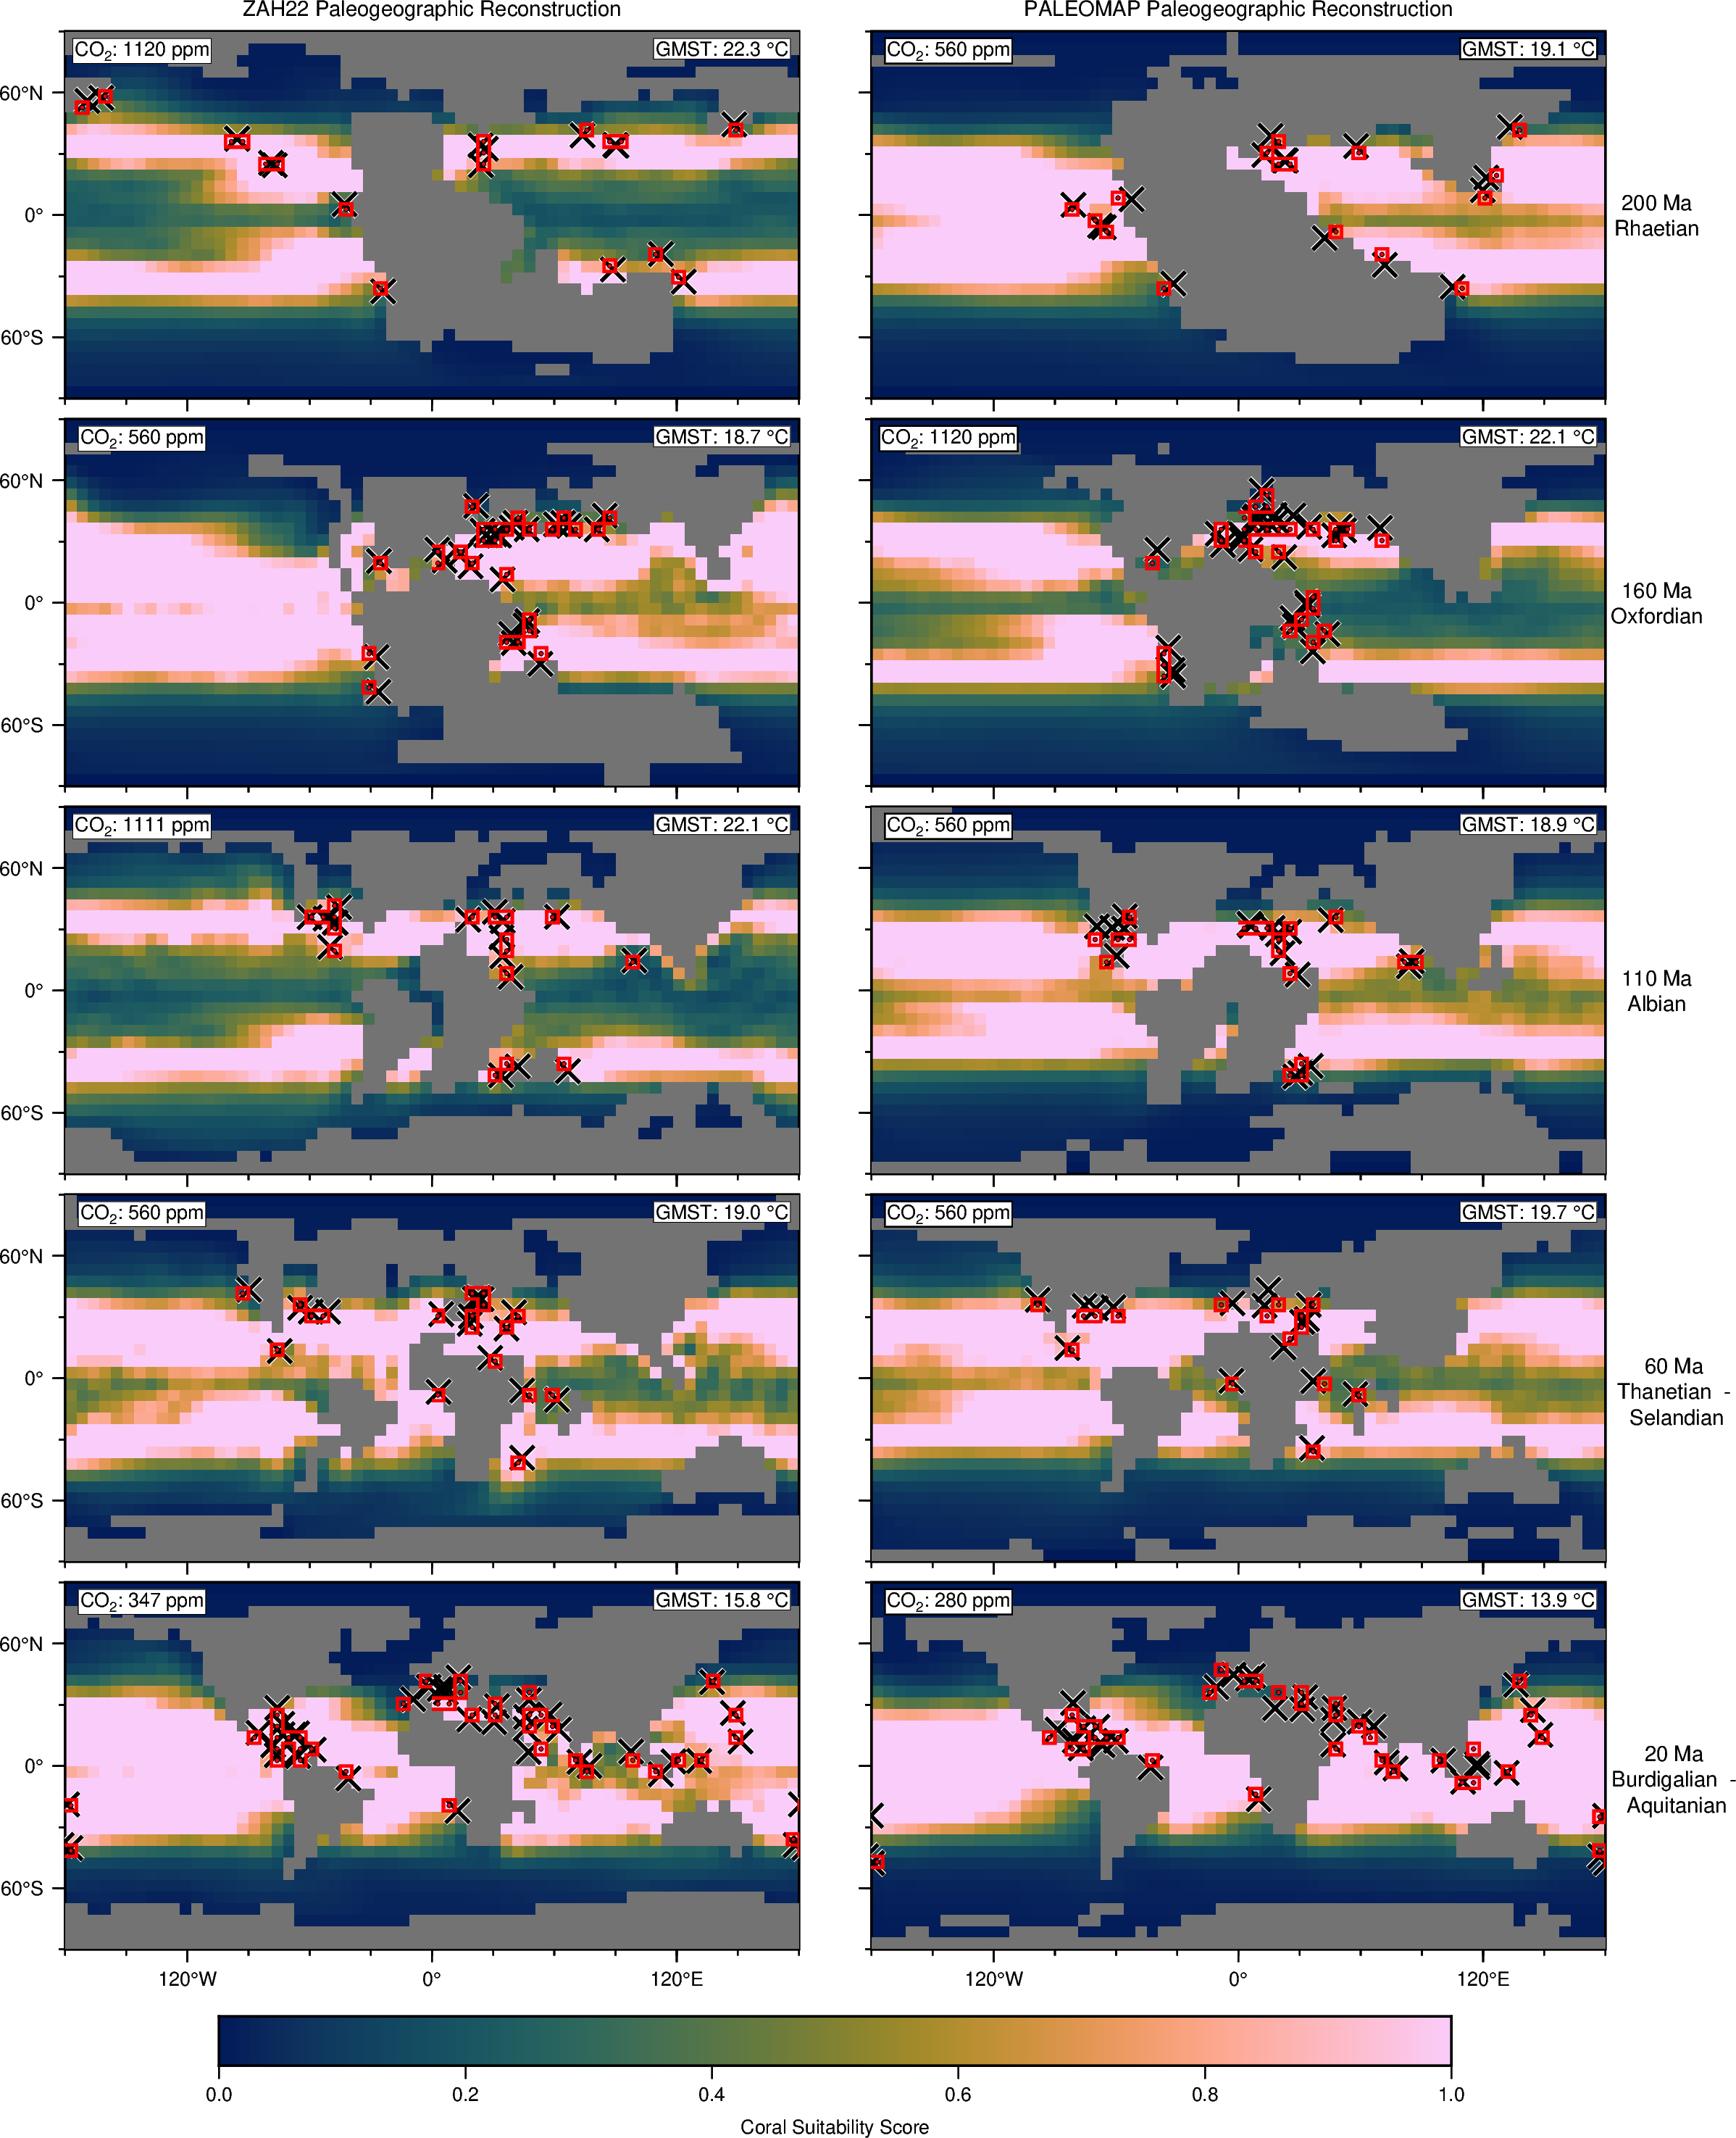

In [367]:
# Figure for a single snapshot
# age = 100
co2_scenario = 'best_scenario'
ebyteScenario.fuzzyModelName = f'proj_earthByte_paleomag/{co2_scenario}'
scoteseScenario.fuzzyModelName = f'proj_scotese/{co2_scenario}'
# scoteseScenario.fuzzyModelName = f'proj_earthByte_paleomag/{co2_scenario}'
ebyteTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Paleotopography_earthbyte/topos_filled_PaleomagRef"
scoteseTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Scotese_1deg_renamed"
ebyteScenario.topoPath = ebyteTopoPath
scoteseScenario.topoPath = scoteseTopoPath

figFolder = 'figures/fuzzy_logic_projection_earthByte_paleomag'
if not os.path.exists(figFolder):
    os.makedirs(figFolder)

fig = pygmt.Figure()
nrows = 5 # Number of rows in the subplot
anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
ages =[204.95,158.15,106.75,58.8, 19.5]
pygmt.config(MAP_FRAME_TYPE="plain")
with fig.subplot(
    nrows=nrows,
    ncols=2,
    figsize=("18c", f"{nrows*4.5}c"),
    sharex="b",
    sharey="l",
    margins=["0.35c", "0c"], 
    frame=['WSrt','xa120f30','ya60f30'],
):
    with fig.set_panel(panel=0):
        fuzzy_logic_projection_plot(fig, ages[0], ebyteScenario, basicParedData, mergedAges, model_prefix='eByte', figFolder=figFolder)
        age10 = (ages[0]+5)//10 * 10
        fig.text(font='7p', text='ZAH22 Paleogeographic Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
        co2 = ebyte_bestScenario[co2_scenario][ages[0]].split('_')[1]
        gmst = ebyte_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[0])
        
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=1):
        fuzzy_logic_projection_plot(fig, ages[0], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        ageName = mergedAges[(mergedAges['Start'] >= ages[0]) & (mergedAges['End'] < ages[0])]['Name'].values[0]
        age10 = (ages[0]+5)//10 * 10
        fig.text(font='7p', text='PALEOMAP Paleogeographic Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.60c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.60c/0c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{ageName}', position="MR", justify="MC", offset="0.60c/-0.15c",verbose=True, no_clip=True)
        co2 = scotese_bestScenario[co2_scenario][ages[0]].split('_')[1]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[0])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")

        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
    with fig.set_panel(panel=2):
        fuzzy_logic_projection_plot(fig, ages[1], ebyteScenario, basicParedData, mergedAges, model_prefix='eByte', figFolder=figFolder)
        age10 = (ages[1]+5)//10 * 10
        co2 = ebyte_bestScenario[co2_scenario][ages[1]].split('_')[1]
        gmst = ebyte_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[1])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=3):
        fuzzy_logic_projection_plot(fig, ages[1], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        ageName = mergedAges[(mergedAges['Start'] >= ages[1]) & (mergedAges['End'] < ages[1])]['Name'].values[0]
        age10 = (ages[1]+5)//10 * 10
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.60c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.60c/0c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{ageName}', position="MR", justify="MC", offset="0.60c/-0.15c",verbose=True, no_clip=True)
        co2 = scotese_bestScenario[co2_scenario][ages[1]].split('_')[1]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[1])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=4):
        fuzzy_logic_projection_plot(fig, ages[2], ebyteScenario, basicParedData, mergedAges, model_prefix='eByte', figFolder=figFolder)
        age10 = (ages[2]+5)//10 * 10
        co2 = ebyte_bestScenario[co2_scenario][ages[2]].split('_')[1]
        gmst = ebyte_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[2])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=5):
        fuzzy_logic_projection_plot(fig, ages[2], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        ageName = mergedAges[(mergedAges['Start'] >= ages[2]) & (mergedAges['End'] < ages[2])]['Name'].values[0]
        age10 = (ages[2]+5)//10 * 10
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.60c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.60c/0c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{ageName}', position="MR", justify="MC", offset="0.60c/-0.15c",verbose=True, no_clip=True)
        co2 = scotese_bestScenario[co2_scenario][ages[2]].split('_')[1]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[2])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=6):
        fuzzy_logic_projection_plot(fig, ages[3], ebyteScenario, basicParedData, mergedAges, model_prefix='eByte', figFolder=figFolder)
        age10 = (ages[3]+5)//10 * 10
        co2 = ebyte_bestScenario[co2_scenario][ages[3]].split('_')[1]
        gmst = ebyte_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[3])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=7):
        fuzzy_logic_projection_plot(fig, ages[3], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        ageName = mergedAges[(mergedAges['Start'] >= ages[3]) & (mergedAges['End'] < ages[3])]['Name'].values[0].split('-')
        age10 = (ages[3]+5)//10 * 10
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[0]} -', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.80c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.80c/0c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'{ageName}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        co2 = scotese_bestScenario[co2_scenario][ages[3]].split('_')[1]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[3])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")

        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=8):
        fuzzy_logic_projection_plot(fig, ages[4], ebyteScenario, basicParedData, mergedAges, model_prefix='eByte', figFolder=figFolder)
        age10 = (ages[4]+5)//10 * 10
        co2 = ebyte_bestScenario[co2_scenario][ages[4]].split('_')[1]
        gmst = ebyte_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[4])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=9):
        fuzzy_logic_projection_plot(fig, ages[4], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        age10 = (ages[4]+5)//10 * 10
        ageName = mergedAges[(mergedAges['Start'] >= ages[4]) & (mergedAges['End'] < ages[4])]['Name'].values[0].split('-')
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[0]} -', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)
        
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.80c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.80c/0c",verbose=True, no_clip=True)
        
        co2 = scotese_bestScenario[co2_scenario][ages[4]].split('_')[1]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[4])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")

        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")

fig.colorbar(frame='a0.2+lCoral Suitability Score', position="JBC", box=None, cmap='reefProbFuzzy.cpt', verbose=True)
fig.show()
fig.savefig(f'{figFolder}/fuzzy_logic_snapshots_best_scenario.png', dpi=300)

### Animation

In [368]:
# mergedAges.head(60)
ageName = mergedAges[(mergedAges['Start'] >= ages[3]) & (mergedAges['End'] < ages[3])]['Name'].values[0]
ageName

'Thanetian - Selandian'

In [369]:
inputDir = f'data/fuzzy_logic_projection_narrow/proj_earthByte_paleomag/best_scenario'
print(inputDir)

data/fuzzy_logic_projection_narrow/proj_earthByte_paleomag/best_scenario


In [370]:
figFolder = 'figures/animation'
if not os.path.exists(figFolder):
    os.makedirs(figFolder)
for file in os.listdir(inputDir):
    if file.endswith('.nc'):
        age = float(file.replace('Ma.nc',''))
        age10 = (age + 5)//10 * 10
        print(age)
        fig = pygmt.Figure()
        nrows = 1 # Number of rows in the subplot
        anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
        ages =[217.75,158.15,117.2,97.2,58.8, 19.5]
        pygmt.config(MAP_FRAME_TYPE="plain")
        with fig.subplot(
            nrows=nrows,
            ncols=1,
            figsize=("18c", f"{nrows*4.5}c"),
            sharex="b",
            sharey="l",
            margins=["0.35c", "0c"], 
            frame=['WSrt','xa120f30','ya60f30'],
        ):
            with fig.set_panel(panel=0):
                fuzzy_logic_projection_plot(fig, age, ebyteScenario, basicParedData, mergedAges, model_prefix='eByte', figFolder=figFolder)
                fig.text(font='7p', text=f'{int(age10)} Ma', position="TR", justify="MC", offset="-0.6c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        # fig.show()
        fig.savefig(f'{figFolder}/{age}_bestCase.png', dpi=300)

106.75
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[2.8749125]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 30.94
  * latitude   (latitude) float32 4B -41.55
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.0748076]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 64.69
  * latitude   (latitude) float32 4B -36.01


pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: tmp.nc -CreefProbFuzzy.cpt -JQ7.0866i -Rd -V -nb -Xa0i -Ya0i -Bxa120f30 -Bya60f30 -BWrtS
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4447.69 km per cm or 1:4.44769e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp.nc
grdimage [INFORMATION]: Grid x-coordinates after pixel registration adjustment have exactly 360 range
grdimage [INFORMATION]: No range attribute, guessing registration to be pixel
grdimage [WARNING]: The step size of coordinate (lat) in grid tmp.nc is not cons

<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[5.6343136]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 36.56
  * latitude   (latitude) float32 4B -36.01
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.0886693]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 36.56
  * latitude   (latitude) float32 4B -36.01
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.8061035]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 36.56
  * latitude   (latitude) float32 4B -36.01


PSL: Too many colors to make colormap - using 24-bit direct color instead.
PSL: DEFLATE compressed 6144 to 2361 bytes (61.6% savings at compression level 5)
grdimage [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid climateData.nc is not constant.
grdimage [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale is 4447.69 km per cm or 1:4.44769e+08.


Number of data points: 17
Number of data points to nearest model cell: 17
69.05
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[5.420519]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 8.438
  * latitude   (latitude) float32 4B 36.01
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.918944]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 300.9
  * latitude   (latitude) float32 4B 36.01


...

Number of data points: 21
Number of data points to nearest model cell: 21
125.4
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.4725041]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 165.9
  * latitude   (latitude) float32 4B 47.09
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.8496923]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 340.3
  * latitude   (latitude) float32 4B 13.85
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[4.373912]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 47.81
  * latitude   (latitude) float32 4B 36.01


pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: tmp.nc -CreefProbFuzzy.cpt -JQ7.0866i -Rd -V -nb -Xa0i -Ya0i -Bxa120f30 -Bya60f30 -BWrtS
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4447.69 km per cm or 1:4.44769e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp.nc


<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[5.1927757]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 42.19
  * latitude   (latitude) float32 4B 36.01
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[5.5503225]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 42.19
  * latitude   (latitude) float32 4B 36.01
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[3.5761933]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 165.9
  * latitude   (latitude) float32 4B 47.09
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[5.2764263]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 42.19
  * latitude   (latitude) float32 4B 36.01
<xarray.DataArray (longitude: 1, latitude: 1)> Size: 4B
array([[5.175114]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 4B 42.19
  * latitude   (latitude) float32 4B 36.01
<xarray.DataArray (longitude: 1, latitude

grdimage [INFORMATION]: Grid x-coordinates after pixel registration adjustment have exactly 360 range
grdimage [INFORMATION]: No range attribute, guessing registration to be pixel
grdimage [WARNING]: The step size of coordinate (lat) in grid tmp.nc is not constant.
grdimage [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdimage [INFORMATION]: netCDF grid tmp.nc has no default CPT.
grdimage [INFORMATION]: netCDF grid tmp.nc information has zmin = zmax = NaN. Reset to 0/0.
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Map scale is 4447.69 km per cm or 1:4.44769e+08.
grdimage [INFORMATION]: Allocate and read data from file tmp.nc
grdimage [INFORMATION]: Reading grid from file tmp.nc
grdimage [INFORMATION]: gmt_grd_BC_set: Set boundary condition for top    edge: natural
grdimage [INFORMATION]: gmt_grd_BC_set: Set boundary condition for bottom edge: natural
grdimage [INFORMATION]: gmt_cpt_default: Use spe

Number of data points: 11
Number of data points to nearest model cell: 11


In [371]:
import imageio
import re
def animation(directory,name='animation.gif'):
    def extract_starting_integer(s):
        match = re.match(r'(\d+)', s)
        return int(match.group(1)) if match else float('inf')

    images = []
    for im in sorted(os.listdir(directory), key=extract_starting_integer):
        print(im)
        if not im.endswith('png'):
            continue
        images.append(imageio.v2.imread(f'{directory}/{im}'))
    imageio.mimwrite(f'{directory}/{name}',images, duration=500)

animation(figFolder, name='fuzzy_logic_projection_earthByte_paleomag_best_scenario.gif')

0.0041_bestCase.png
0.9645_bestCase.png
3.9565_bestCase.png
8.4815_bestCase.png
13.8_bestCase.png
19.5_bestCase.png
25.425_bestCase.png
32.765_bestCase.png
39.455_bestCase.png
44.5_bestCase.png
51.9_bestCase.png
58.8_bestCase.png
69.05_bestCase.png
77.85_bestCase.png
86.7_bestCase.png
91.85_bestCase.png
97.2_bestCase.png
106.75_bestCase.png
117.2_bestCase.png
125.4_bestCase.png
131.0_bestCase.png
136.2_bestCase.png
149.9_bestCase.png
158.15_bestCase.png
164.85_bestCase.png
171.45_bestCase.png
179.15_bestCase.png
188.55_bestCase.png
197.15_bestCase.png
204.95_bestCase.png
217.75_bestCase.png
232.0_bestCase.png
239.5_bestCase.png
246.6_bestCase.png
climate_scenario_overlaps_scotese.txt
climate_scenario_overlaps.txt
fuzzy_logic_projection_earthByte_paleomag_best_scenario.gif
fuzzy_logic_paleotemperature_curves.png


ValueError: all input arrays must have the same shape

# Paleotemps comparison

In [383]:
scotese_bestScenario

,best_scenario
0.0041,scotese_280
0.0686,NaN
0.9645,scotese_280
3.9565,scotese_280
8.4815,scotese_280
...,...
497.2500,NaN
504.7500,NaN
511.5000,NaN
517.5000,NaN


0.0041: scotese_280 -> 280
0.9645: scotese_280 -> 280
3.9565: scotese_280 -> 280
8.4815: scotese_280 -> 560
13.8: nan -> fosterCO2
nan
Error occurred: 'float' object has no attribute 'split'
19.5: scotese_280 -> fosterCO2
25.425: scotese_560 -> 280
32.765: scotese_560 -> 560
39.455: scotese_280 -> 280
44.5: scotese_280 -> 280
51.9: scotese_560 -> 560
58.8: scotese_560 -> 560
69.05: scotese_560 -> 560
77.85: scotese_560 -> 1120
86.69999999999999: scotese_2240 -> 1120
91.85: scotese_2240 -> 1120
97.2: scotese_560 -> 1120
106.75: scotese_560 -> fosterCO2
117.2: scotese_560 -> 560
125.4: scotese_1120 -> 2240
131.0: scotese_2240 -> 1120
136.2: scotese_1120 -> fosterCO2
149.9: scotese_1120 -> 560
158.15: scotese_1120 -> 560
164.85: scotese_560 -> 560
171.45: nan -> fosterCO2
nan
Error occurred: 'float' object has no attribute 'split'
179.14999999999998: scotese_2240 -> fosterCO2
188.55: scotese_fosterCO2 -> fosterCO2
197.15: scotese_2240 -> 2240
204.95: scotese_560 -> 1120
217.75: scotese_56

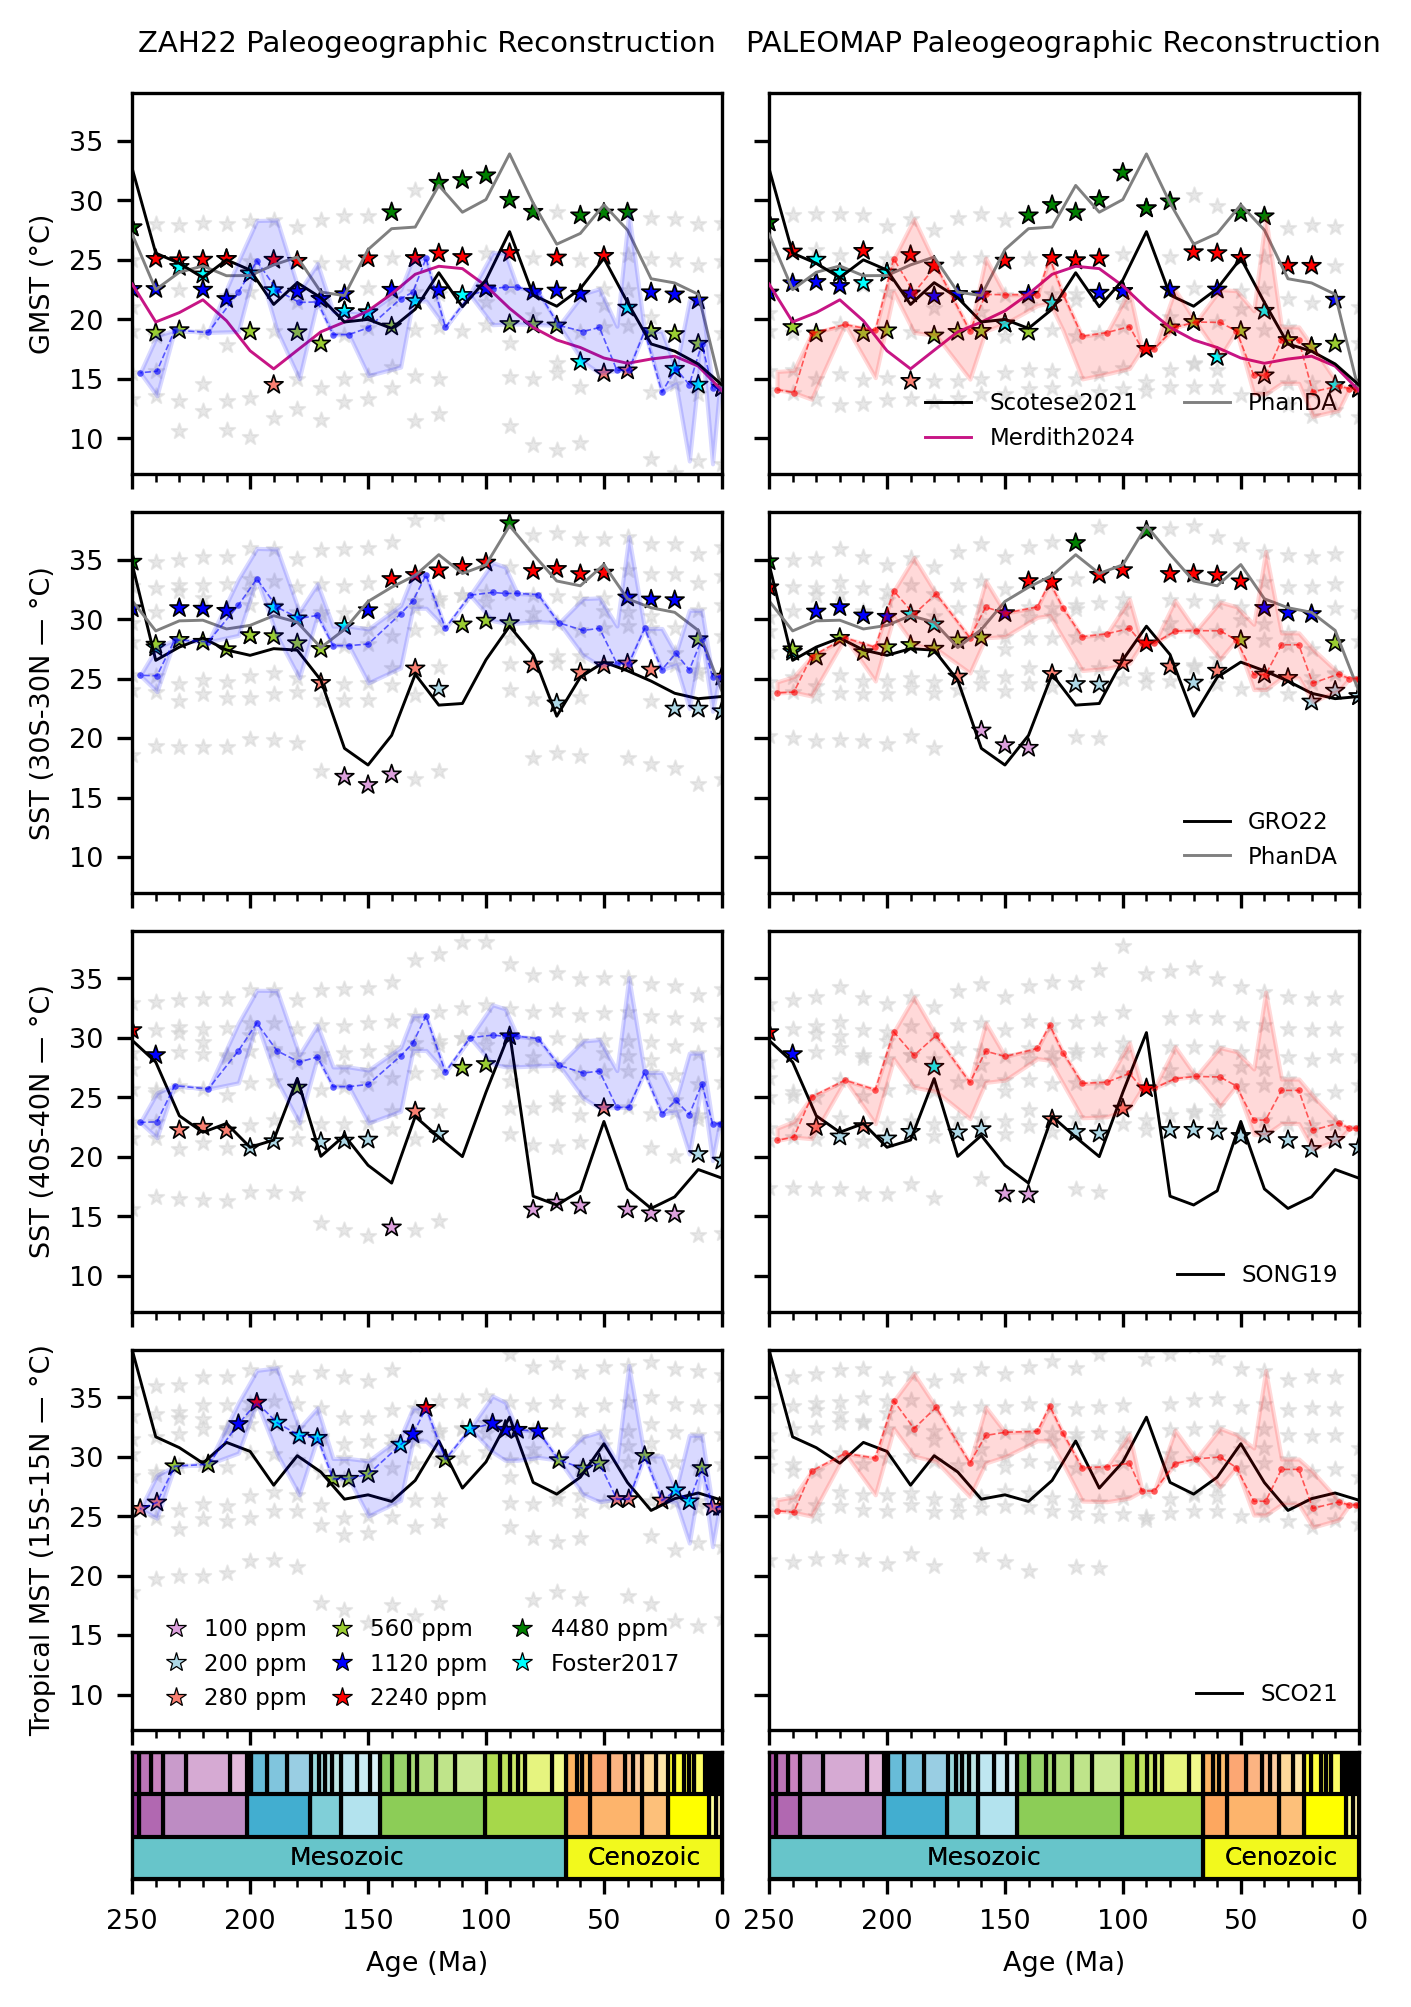

In [ ]:
colours = ['plum','lightblue','salmon','yellowgreen','blue','red','green','cyan','orange','pink']
colourDict = {}
ptempCurveColours =['black','mediumvioletred','grey']
ptempCurveLinewidth = 0.7
co2MarkerSize = 15
co2MarkerLinewidth = 0.5

markers = []
labels = []
for i, co2 in enumerate(co2s):
    colour = colours[i]
    colourDict[co2] = colour
    marker = mlines.Line2D([], [], color=colour, marker='*', linestyle='None', markersize=5, markeredgewidth=0.3, markeredgecolor='black', label=f'{co2}')
    markers.append(marker)

    if co2 == 'fosterCO2':
        label = 'Foster2017'
    else:
        label = f'{co2} ppm'
    labels.append(label)
# Plot all four figures
fig, axs = plt.subplots(4, 2, figsize=(134*mm,180*mm), dpi=300, sharex=True, sharey=True)
plt.rcParams['font.size']=6.5
plt.subplots_adjust(wspace=0.08, hspace=0.1)  # Reduce horizontal and vertical space between subplots
# Set Y-axis limits
axs[0,0].set_ylim(7, 39)
axs[0,0].set_xlim(255,-3.2)
axs[0,0].set_xticks(np.arange(0, 251, 50))
axs[0,0].set_xticks(np.arange(0, 251, 10), minor=True)
axs[0,0].xaxis.remove_overlapping_locs = False

for i, co2 in enumerate(co2s): 
    axs[0, 0].scatter(x=ebyte_modelGMST_df.index, y=ebyte_modelGMST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[0, 1].scatter(x=scotese_modelGMST_df.index, y=scotese_modelGMST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[1, 0].scatter(x=ebyte_modelSST_df.index, y=ebyte_modelSST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[1, 1].scatter(x=scotese_modelSST_df.index, y=scotese_modelSST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[2, 0].scatter(x=ebyte_songSST_df.index, y=ebyte_songSST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[2, 1].scatter(x=scotese_songSST_df.index, y=scotese_songSST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[3, 0].scatter(x=ebyte_model_tropicalAirTemp.index, y=ebyte_model_tropicalAirTemp[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[3, 1].scatter(x=scotese_model_tropicalAirTemp.index, y=scotese_model_tropicalAirTemp[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)

for i, paleotempCurve in enumerate(ebyte_tropicalAirCurve_df.columns):
    axs[3,0].plot(ebyte_tropicalAirCurve_df.index, ebyte_tropicalAirCurve_df[paleotempCurve], linewidth=ptempCurveLinewidth, color=ptempCurveColours[i], linestyle='-', label='SCO21')
    axs[3,1].plot(scotese_tropicalAirCurve_df.index, scotese_tropicalAirCurve_df[paleotempCurve], linewidth=ptempCurveLinewidth, color=ptempCurveColours[i], linestyle='-', label='SCO21')
    tropicalAirDict_ebyte = {}
    tropicalAirDict_scotese = {}
    colours_ebyte = {}
    colours_scotese = {}
    # for age in ebyte_matchingScenarios.index:
    #     co2 = ebyte_matchingScenarios.loc[age, paleotempCurve]
    #     tropicalAirDict_ebyte[age] = ebyte_model_tropicalAirTemp.loc[age, co2]
    #     colours_ebyte[age] = colourDict[co2]

    #     co2 = scotese_matchingScenarios.loc[age, paleotempCurve]
    #     tropicalAirDict_scotese[age] = scotese_model_tropicalAirTemp.loc[age, co2]
    #     colours_scotese[age] = colourDict[co2]
    # try:
        # axs[3,0].scatter(x=list(tropicalAirDict_ebyte.keys()),y=list(tropicalAirDict_ebyte.values()), marker='*', facecolors=list(colours_ebyte.values()), edgecolors='black', linewidths=0.4, s=co2MarkerSize*1.5)
        # axs[3,1].scatter(x=list(tropicalAirDict_scotese.keys()),y=list(tropicalAirDict_scotese.values()), marker='*', facecolors=list(colours_scotese.values()), edgecolors='black', linewidths=0.4, s=co2MarkerSize*1.5)
    # except:
        # continue

for i, paleotempCurve in enumerate(ebyte_songSSTcurve_df.columns):
    axs[2,0].plot(ebyte_songSSTcurve_df.index, ebyte_songSSTcurve_df[paleotempCurve], linewidth=ptempCurveLinewidth, color=ptempCurveColours[i], linestyle='-', label='SONG19')
    axs[2,1].plot(scotese_songSSTcurve_df.index, scotese_songSSTcurve_df[paleotempCurve], linewidth=ptempCurveLinewidth, color=ptempCurveColours[i], linestyle='-', label='SONG19')

    songDict_ebyte = {}
    songDict_scotese = {}
    colours_ebyte = {}
    colours_scotese = {}
    for age in ebyte_matchingScenarios.index:
        co2 = ebyte_matchingScenarios.loc[age, paleotempCurve]
        songDict_ebyte[age] = ebyte_songSST_df.loc[age, co2]
        colours_ebyte[age] = colourDict[co2]

        co2 = scotese_matchingScenarios.loc[age, paleotempCurve]
        songDict_scotese[age] = scotese_songSST_df.loc[age, co2]
        colours_scotese[age] = colourDict[co2]
    
    try:
        axs[2,0].scatter(x=list(songDict_ebyte.keys()),y=list(songDict_ebyte.values()), marker='*', facecolors=list(colours_ebyte.values()), edgecolors='black', linewidths=0.4, s=co2MarkerSize*1.5)
        axs[2,1].scatter(x=list(songDict_scotese.keys()),y=list(songDict_scotese.values()), marker='*', facecolors=list(colours_scotese.values()), edgecolors='black', linewidths=0.4, s=co2MarkerSize*1.5)
    except:
        continue

for i, paleotempCurve in enumerate(ebyte_SSTcurve_df.columns):
    # axs[1,0].plot(ebyte_SSTcurve_df.index, ebyte_SSTcurve_df[paleotempCurve], linewidth=1, color=ptempCurveColours[i], linestyle='-', label=paleotempCurve.split('_')[0])
    if i ==0:
        axs[1,0].plot(ebyte_SSTcurve_df.index, ebyte_SSTcurve_df[paleotempCurve], linewidth=ptempCurveLinewidth, color=ptempCurveColours[i], linestyle='-', label='GRO22')
        axs[1,1].plot(scotese_SSTcurve_df.index, scotese_SSTcurve_df[paleotempCurve], linewidth=ptempCurveLinewidth, color=ptempCurveColours[i], linestyle='-', label='GRO22')
    if i == 1:
        axs[1,0].plot(ebyte_SSTcurve_df.index, ebyte_SSTcurve_df[paleotempCurve], linewidth=ptempCurveLinewidth, color=ptempCurveColours[2], linestyle='-', label='PhanDA')
        axs[1,1].plot(scotese_SSTcurve_df.index, scotese_SSTcurve_df[paleotempCurve], linewidth=ptempCurveLinewidth, color=ptempCurveColours[2], linestyle='-', label='PhanDA')

    sstDict_ebyte = {}
    sstDict_scotese = {}
    colours_ebyte = {}
    colours_scotese = {}
    for age in ebyte_matchingScenarios.index:
        co2 = ebyte_matchingScenarios.loc[age, paleotempCurve]
        sstDict_ebyte[age] = ebyte_modelSST_df.loc[age, co2]
        colours_ebyte[age] = colourDict[co2]

        co2 = scotese_matchingScenarios.loc[age, paleotempCurve]
        sstDict_scotese[age] = scotese_modelSST_df.loc[age, co2]
        colours_scotese[age] = colourDict[co2]

    try:
        axs[1,0].scatter(x=list(sstDict_ebyte.keys()),y=list(sstDict_ebyte.values()), marker='*', facecolors=list(colours_ebyte.values()), edgecolors='black', linewidths=0.4, s=co2MarkerSize*1.5)
        axs[1,1].scatter(x=list(sstDict_scotese.keys()),y=list(sstDict_scotese.values()), marker='*', facecolors=list(colours_scotese.values()), edgecolors='black', linewidths=0.4, s=co2MarkerSize*1.5)
    except:
        continue  

for i,paleotempCurve in enumerate(ebyte_GMSTcurve_df.columns):
    # ebyte GMST curve is the paleotemp reconstruction so will be the same fro ebyte and scotese
    axs[0, 0].plot(ebyte_matchingScenarios.index, ebyte_GMSTcurve_df[paleotempCurve], linewidth=ptempCurveLinewidth, color=ptempCurveColours[i], linestyle='-', label=paleotempCurve.split('_')[0], zorder=5-i)
    axs[0, 1].plot(scotese_matchingScenarios.index, scotese_GMSTcurve_df[paleotempCurve], linewidth=ptempCurveLinewidth, color=ptempCurveColours[i], linestyle='-', label=paleotempCurve.split('_')[0], zorder=5-i)

    tempDict_ebyte = {}
    tempDict_scotese = {}
    colours_ebyte = {}
    colours_scotese = {}
    for age in ebyte_matchingScenarios.index:
        co2 = ebyte_matchingScenarios.loc[age, paleotempCurve]
        tempDict_ebyte[age] = ebyte_modelGMST_df.loc[age, co2]
        colours_ebyte[age] = colourDict[co2]

        co2 = scotese_matchingScenarios.loc[age, paleotempCurve]
        tempDict_scotese[age] = scotese_modelGMST_df.loc[age, co2]
        colours_scotese[age] = colourDict[co2]

    try:
        axs[0,0].scatter(x=list(tempDict_ebyte.keys()),y=list(tempDict_ebyte.values()), marker='*', facecolors=list(colours_ebyte.values()), edgecolors='black', linewidths=0.4, s=co2MarkerSize*1.5)
        axs[0,1].scatter(x=list(tempDict_scotese.keys()),y=list(tempDict_scotese.values()), marker='*', facecolors=list(colours_scotese.values()), edgecolors='black', linewidths=0.4, s=co2MarkerSize*1.5)
    except:
        continue

# Add in the ideal scenario based on coral likelihood
axs[0,0].plot(optimalCO2s_ebyte.keys(), list(zip(*optimalCO2s_ebyte.values()))[2], linewidth=0.4, color='blue', alpha=0.6, linestyle='--', label='Coral Match (ZAH22)')
axs[0,0].scatter(optimalCO2s_ebyte.keys(), list(zip(*optimalCO2s_ebyte.values()))[2], marker='o', color='blue', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[0,0].fill_between(optimalCO2s_ebyte.keys(), GMSTS_min_ebyte, GMSTS_max_ebyte, color='blue', alpha=0.15, zorder=30)

axs[0,1].plot(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[2], linewidth=0.4, color='red', alpha=0.6, linestyle='--', label='Coral Match (PALEOMAP)')
axs[0,1].scatter(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[2], marker='o', color='red', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[0,1].fill_between(optimalCO2s_scotese.keys(), GMSTS_min_scotese, GMSTS_max_scotese, color='red', alpha=0.15, zorder=30)

axs[1,0].plot(optimalCO2s_ebyte.keys(), list(zip(*optimalCO2s_ebyte.values()))[4], linewidth=0.4, color='blue', alpha=0.6, linestyle='--', label='Coral Match (ZAH22)')
axs[1,0].scatter(optimalCO2s_ebyte.keys(), list(zip(*optimalCO2s_ebyte.values()))[4], marker='o', color='blue', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[1,0].fill_between(optimalCO2s_ebyte.keys(), SSTs_min_ebyte, SSTs_max_ebyte, color='blue', alpha=0.15, zorder=30)

axs[1,1].plot(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[4], linewidth=0.4, color='red', alpha=0.6, linestyle='--', label='Coral Match (PALEOMAP)')
axs[1,1].scatter(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[4], marker='o', color='red', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[1,1].fill_between(optimalCO2s_scotese.keys(), SSTs_min_scotese, SSTs_max_scotese, color='red', alpha=0.15, zorder=30)

axs[2,0].plot(optimalCO2s_ebyte.keys(), list(zip(*optimalCO2s_ebyte.values()))[6], linewidth=0.4, color='blue', alpha=0.6, linestyle='--', label='Coral Match (ZAH22)')
axs[2,0].scatter(optimalCO2s_ebyte.keys(), list(zip(*optimalCO2s_ebyte.values()))[6], marker='o', color='blue', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[2,0].fill_between(optimalCO2s_ebyte.keys(), songSSTs_min_ebyte, songSSTs_max_ebyte, color='blue', alpha=0.15, zorder=30)

axs[2,1].plot(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[6], linewidth=0.4, color='red', alpha=0.6, linestyle='--', label='Coral Match (PALEOMAP)')
axs[2,1].scatter(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[6], marker='o', color='red', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[2,1].fill_between(optimalCO2s_scotese.keys(), songSSTs_min_scotese, songSSTs_max_scotese, color='red', alpha=0.15, zorder=30)

axs[3,0].plot(optimalCO2s_ebyte.keys(), list(zip(*optimalCO2s_ebyte.values()))[8], linewidth=0.4, color='blue', alpha=0.6, linestyle='--', label='Coral Match (ZAH22)')
axs[3,0].scatter(optimalCO2s_ebyte.keys(), list(zip(*optimalCO2s_ebyte.values()))[8], marker='o', color='blue', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[3,0].fill_between(optimalCO2s_ebyte.keys(), tropicalAirTemps_min_ebyte, tropicalAirTemps_max_ebyte, color='blue', alpha=0.15, zorder=30)

axs[3,1].plot(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[8], linewidth=0.4, color='red', alpha=0.6, linestyle='--', label='Coral Match (PALEOMAP)')
axs[3,1].scatter(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[8], marker='o', color='red', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[3,1].fill_between(optimalCO2s_scotese.keys(), tropicalAirTemps_min_scotese, tropicalAirTemps_max_scotese, color='red', alpha=0.15, zorder=30)

colours_ebyte = {}
colours_scotese = {}
for age in optimalCO2s_ebyte.keys():
    try:
        co2= ebyte_bestScenario['best_scenario'][age].split('_')[1]
        colours_ebyte[age] = colourDict[co2]

        
        co2= scotese_bestScenario['best_scenario'][age].split('_')[1]
        print(f'{age}: {scotese_bestScenario["best_scenario"][age]} -> {co2}')
        colours_scotese[age] = colourDict[co2]
    except Exception as e:
        print(f'{scotese_bestScenario['best_scenario'][age]}')
        print(f"Error occurred: {e}")
        
        continue

    
try:
    axs[3,0].scatter(x=list(optimalCO2s_ebyte.keys()),y=list(zip(*optimalCO2s_ebyte.values()))[8], marker='*', facecolors=list(colours_ebyte.values()), edgecolors='black', linewidths=0.4, s=co2MarkerSize*1.5)
    # axs[3,1].scatter(x=list(tropicalAirDict_scotese.keys()),y=list(tropicalAirDict_scotese.values()), marker='*', facecolors=list(colours_scotese.values()), edgecolors='black', linewidths=0.4, s=co2MarkerSize*1.5)
except Exception as e:
    print(f"Error occurred: {e}")
    pass

# Set the x and y labels
axs[0, 0].set_ylabel('GMST (°C)', labelpad=3, fontsize=6.5)
axs[1, 0].set_ylabel('SST (30S-30N — °C)', labelpad=3, fontsize=6.5)
axs[2, 0].set_ylabel('SST (40S-40N — °C)', labelpad=3, fontsize=6.5)
axs[3, 0].set_ylabel('Tropical MST (15S-15N — °C)', labelpad=3, fontsize=6.5)
# axs[1, 0].set_xlabel('Age (Ma)', labelpad=3, fontsize=6.5)
# axs[1, 1].set_xlabel('Age (Ma)', labelpad=3, fontsize=6.5)
axs[3,0].tick_params(axis='x', labelbottom=False)
axs[3,1].tick_params(axis='x', labelbottom=False)

# Add column headings
axs[0,0].set_title('ZAH22 Paleogeographic Reconstruction', fontsize=7, pad=10)
axs[0,1].set_title('PALEOMAP Paleogeographic Reconstruction', fontsize=7, pad=10)

# Get handles and labels from both subplots
handles_00, labels_00 = axs[0,0].get_legend_handles_labels()
handles_01, labels_01 = axs[0,1].get_legend_handles_labels()
# Combine them
# combined_handles =  handles_01 + [handles_00[-1]]
# combined_labels =  labels_01 + [labels_00[-1]]
best_match_handles = [handles_00[-1], handles_01[-1]]
best_match_labels = [labels_00[-1], labels_01[-1]]
handles_curves = handles_00[:-1]
labels_curves = labels_00[:-1]
# Create legend on axs[0,1] with combined elements
axs[0,1].legend(handles_curves, labels_curves, bbox_to_anchor=(1, 0.01), loc='lower right', frameon=False, fontsize=5.5, ncol=2)
# axs[1,1].legend(loc='upper left', frameon=False, fontsize=6.5)

handles_10, labels_10 = axs[1,0].get_legend_handles_labels()
handles_10 = [handles_10[0]] + [handles_10[1]] 
labels_10 = [labels_10[0]] + [labels_10[1]] 
axs[1,1].legend(handles_10, labels_10, bbox_to_anchor=(1, 0.01), loc='lower right', frameon=False, fontsize=5.5)

handles_20, labels_20 = axs[2,0].get_legend_handles_labels()
handles_20 = [handles_20[0]]
labels_20 = [labels_20[0]]
axs[2,1].legend(handles_20, labels_20, bbox_to_anchor=(1, 0.01), loc='lower right', frameon=False, fontsize=5.5)

handles_30, labels_30 = axs[3,0].get_legend_handles_labels()
handles_30 = [handles_30[0]]
labels_30 = [labels_30[0]]
axs[3,1].legend(handles_30, labels_30, bbox_to_anchor=(1, 0.01), loc='lower right', frameon=False, fontsize=5.5)

axs[3,0].legend(markers, labels, bbox_to_anchor=(0, 0), loc='lower left', frameon=False, fontsize=5.5, ncol=3, handletextpad=0.25, columnspacing=0.5)

# Add the geolgoical scale under the x axis
# eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# Create a new axis below the main plot, sharing the x-axis
ax0 = fig.add_axes([axs[0,0].get_position().x0, 0.04, axs[0,0].get_position().width, 0.06], sharex=axs[0,0])
ax0.set_xlim(250,0)
ax0.set_ylim(0, 1.5)
ax0.yaxis.set_visible(False)
ax0.set_xlabel('Age (Ma)', fontsize=6.5)
# Add x axis tick labels
ax0.set_xticks(np.arange(0, 251, 50))
ax0.set_xticks(np.arange(0, 251, 10), minor=True)

for i, age in geologicalAges.iterrows():
    rect = Rectangle(
        (age['Start'], 0),
        age['End'] - age['Start'],
        1.5,
        facecolor=age['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)


for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)

# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )

ax01 = fig.add_axes([axs[0,1].get_position().x0, 0.04, axs[0,1].get_position().width, 0.06], sharex=axs[0,1])
ax01.set_xlim(250,0)
ax01.set_ylim(0, 1.5)
ax01.yaxis.set_visible(False)
ax01.set_xlabel('Age (Ma)', fontsize=6.5)

for i, age in geologicalAges.iterrows():
    rect = Rectangle(
        (age['Start'], 0),
        age['End'] - age['Start'],
        1.5,
        facecolor=age['Color'],
        edgecolor='k',
        alpha=1
    )
    ax01.add_artist(rect)


for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax01.add_artist(rect)
    # ax0.text(
    #     (epoch['Start'] + epoch['End']) / 2, 
    #     0.75, 
    #     epoch['ShortName'], 
    #     ha='center', 
    #     va='center', 
    #     fontsize=6, 
    #     rotation=0
    # )
# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax01.add_artist(rect)
    ax01.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
    ax01.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )

fig.savefig(f'{figFolder}/fuzzy_logic_paleotemperature_curves.png', dpi=300, transparent=True)



In [395]:
scotese_bestScenario.head(60)
optimalCO2s_ebyte.keys()

dict_keys([0.0041, 0.9645, 3.9565, 8.4815, 13.8, 19.5, 25.425, 32.765, 39.455, 44.5, 51.9, 58.8, 69.05, 77.85, 86.69999999999999, 91.85, 97.2, 106.75, 117.2, 125.4, 131.0, 136.2, 149.9, 158.15, 164.85, 171.45, 179.14999999999998, 188.55, 197.15, 204.95, 217.75, 232.0, 239.5, 246.6])

## Get percentage of overlap

In [361]:
# reload(climateScenario)
ebyteScenario_geoAges = climateScenario.ClimateScenario(ebyteSimulationDirectory, co2s, ebyte_CO2s.index)
scoteseScenario_geoAges = climateScenario.ClimateScenario(scoteseSimulationDirectory, co2s, scotese_CO2s.index)

chosenScenario = ebyteScenario_geoAges
if chosenScenario == ebyteScenario_geoAges:
    optimalCO2s = optimalCO2s_ebyte
    matchingScenarios = ebyte_matchingScenarios
elif chosenScenario == scoteseScenario_geoAges:
    optimalCO2s = optimalCO2s_scotese
    matchingScenarios = scotese_matchingScenarios

merdithTemp_geoAges = chosenScenario.process_merdith(merdith_file, pySCION_classes_path, ages=ebyte_CO2s.index, standalone=True)
scotese_geoAges = chosenScenario.process_scotese(scotese_file, ages=ebyte_CO2s.index, standalone=True)
phanDA_geoAges = chosenScenario.process_phanDA(phanDA_file, ages=ebyte_CO2s.index, standalone=True)
grossman_geoAges = chosenScenario.process_grossman(grossmann_file, ages=ebyte_CO2s.index, standalone=True)
phanDA_sst_geoAges = chosenScenario.process_phanDA_sst(phanDA_SST_file, ages=ebyte_CO2s.index, standalone=True)
song_sst_geoAges = chosenScenario.process_songSST(song_file, ages=ebyte_CO2s.index, standalone=True)
scotese_tropicalAir_geoAges = chosenScenario.process_scotese(scotese_file, ages=ebyte_CO2s.index, standalone=True, tropical=True)
# phanDA_sst_geoAges.head(60)

In [362]:
geoAge_temps = pd.merge(merdithTemp_geoAges, scotese_geoAges, left_index=True, right_index=True, how='outer')
geoAge_temps = pd.merge(geoAge_temps, phanDA_geoAges, left_index=True, right_index=True, how='outer')
geoAge_ssts = pd.merge(grossman_geoAges, phanDA_sst_geoAges, left_index=True, right_index=True, how='outer')
geoAge_song = song_sst_geoAges
geoAge_tropicalAir = scotese_tropicalAir_geoAges

GMST_overlaps = pd.DataFrame(index=optimalCO2s.keys(), columns=geoAge_temps.columns)
difference_from_curve = pd.DataFrame(index=optimalCO2s.keys(), columns=geoAge_temps.columns)
for age in optimalCO2s.keys():
    print('-------------------------------------------------')
    standardError = optimalCO2s[age][-1]
    bestMatchGMST = optimalCO2s[age][2]
    minGMST = np.min(optimalCO2s[age][3]) 
    maxGMST = np.max(optimalCO2s[age][3]) 

    bestMatchSST = optimalCO2s[age][4]
    minSST = np.min(optimalCO2s[age][5]) 
    maxSST = np.max(optimalCO2s[age][5]) 

    bestMatchSST_song = optimalCO2s[age][6]
    minSST_song = np.min(optimalCO2s[age][7]) 
    maxSST_song = np.max(optimalCO2s[age][7]) 

    bestMatch_tropicalAir = optimalCO2s[age][8]
    min_tropicalAir = np.min(optimalCO2s[age][9]) 
    max_tropicalAir = np.max(optimalCO2s[age][9]) 

    print(f'{age} Ma: {minGMST}°C - {maxGMST}°C')
    for col in geoAge_temps.columns:
        temp = geoAge_temps[col][age]
        print(f'GMST range: {minGMST}°C - {maxGMST}°C, Best match: {bestMatchGMST}°C')
        print(f'{col}: {temp}°C')
        if temp > minGMST and temp < maxGMST:
            GMST_overlaps.loc[age, col] = True
            difference_from_curve.loc[age, col] = 0
            # deviation = np.abs(bestMatchGMST - temp)
            # percentDeviation = deviation/abs(bestMatchGMST)*100
            # difference_from_curve.loc[age, col] = percentDeviation
        elif not temp or np.isnan(temp):
            GMST_overlaps.loc[age, col] = np.nan
            difference_from_curve.loc[age, col] = np.nan
        else:
            GMST_overlaps.loc[age, col] = False
            deviation = min(np.abs(minGMST - temp), np.abs(maxGMST - temp))
            percentDeviation = min(deviation / abs(minGMST), deviation / abs(maxGMST))*100
            # deviation = np.abs(bestMatchGMST - temp)
            # percentDeviation = deviation/abs(bestMatchGMST)*100
            difference_from_curve.loc[age, col] = percentDeviation
        print(f'GMST deviation from curve: {difference_from_curve.loc[age, col]}%\n')
        

    for col in geoAge_ssts.columns:
        sst = geoAge_ssts[col][age]
        print(f'SST 30S to 30N range: {minSST}°C - {maxSST}°C, Best match: {bestMatchSST}°C')
        print(f'{col}: {sst}°C')
        if sst > minSST and sst < maxSST:
            GMST_overlaps.loc[age, col] = True
            difference_from_curve.loc[age, col] = 0
        elif not sst or np.isnan(sst):
            GMST_overlaps.loc[age, col] = np.nan
            difference_from_curve.loc[age, col] = np.nan
        else:
            GMST_overlaps.loc[age, col] = False
            # difference_from_curve.loc[age, col] = np.abs(min(np.abs(minSST - sst), np.abs(maxSST - sst)))
            deviation = min(np.abs(minSST - sst), np.abs(maxSST - sst))
            percentDeviation = min(deviation / abs(minSST), deviation / abs(maxSST))*100
            difference_from_curve.loc[age, col] = percentDeviation
        print(f'30S- 30N SST deviation from curve: {difference_from_curve.loc[age, col]}%\n')

    for col in geoAge_song.columns:
        song_sst = geoAge_song[col][age]
        print(f'SST 40S to 40N range: {minSST_song}°C - {maxSST_song}°C, Best match: {bestMatchSST_song}°C')
        print(f'{col}: {song_sst}°C')
        if song_sst > minSST_song and song_sst < maxSST_song:
            GMST_overlaps.loc[age, col] = True
            difference_from_curve.loc[age, col] = 0
        elif not song_sst or np.isnan(song_sst):
            GMST_overlaps.loc[age, col] = np.nan
            difference_from_curve.loc[age, col] = np.nan
        else:
            GMST_overlaps.loc[age, col] = False
            # difference_from_curve.loc[age, col] = np.abs(min(np.abs(minSST_song - song_sst), np.abs(maxSST_song - song_sst)))
            deviation = min(np.abs(minSST_song - song_sst), np.abs(maxSST_song - song_sst))
            percentDeviation = min(deviation / abs(minSST_song), deviation / abs(maxSST_song))*100
            difference_from_curve.loc[age, col] = percentDeviation
        print(f'40S- 40N SST deviation from curve: {difference_from_curve.loc[age, col]}%\n')

    for col in geoAge_tropicalAir.columns:
        tropical_air = geoAge_tropicalAir[col][age]
        print(f'Tropical Air 15S to 15N range: {min_tropicalAir}°C - {max_tropicalAir}°C, Best match: {bestMatch_tropicalAir}°C')
        print(f'{col}: {tropical_air}°C')
        if tropical_air > min_tropicalAir and tropical_air < max_tropicalAir:
            GMST_overlaps.loc[age, col] = True
            difference_from_curve.loc[age, col] = 0
        elif not tropical_air or np.isnan(tropical_air):
            GMST_overlaps.loc[age, col] = np.nan
            difference_from_curve.loc[age, col] = np.nan
        else:
            GMST_overlaps.loc[age, col] = False
            # difference_from_curve.loc[age, col] = np.abs(min(np.abs(min_tropicalAir - tropical_air), np.abs(max_tropicalAir - tropical_air)))
            deviation = min(np.abs(min_tropicalAir - tropical_air), np.abs(max_tropicalAir - tropical_air))
            percentDeviation = min(deviation / abs(min_tropicalAir), deviation / abs(max_tropicalAir))*100
            difference_from_curve.loc[age, col] = percentDeviation
        print(f'Tropical Air deviation from curve: {difference_from_curve.loc[age, col]}%\n')


-------------------------------------------------
0.0041 Ma: 14.2548°C - 14.2548°C
GMST range: 14.2548°C - 14.2548°C, Best match: 14.2548°C
Merdith2024_pyscion: 14.084004651751012°C
GMST deviation from curve: 1.1981602565380576%

GMST range: 14.2548°C - 14.2548°C, Best match: 14.2548°C
Scotese2021_paleotemps: 14.3705655°C
GMST deviation from curve: 0.8121159188483893%

GMST range: 14.2548°C - 14.2548°C, Best match: 14.2548°C
PhanDA_paleotemps: nan°C
GMST deviation from curve: nan%

SST 30S to 30N range: 25.168°C - 25.168°C, Best match: 25.168°C
tropicalSST: 23.47492139018241°C
30S- 30N SST deviation from curve: 6.7271082716846395%

SST 30S to 30N range: 25.168°C - 25.168°C, Best match: 25.168°C
PhanDA_SST_paleotemps: 23.96593674°C
30S- 30N SST deviation from curve: 4.776157263191351%

SST 40S to 40N range: 22.80794906616211°C - 22.80794906616211°C, Best match: 22.80794906616211°C
songSST: 17.509999999999998°C
40S- 40N SST deviation from curve: 23.22852024438336%

Tropical Air 15S to 15

In [363]:
# difference_from_curve
for col in difference_from_curve.columns:
    # print average difference for ages under 200 Ma
    print('-------------------------------------------------')
    print(f'{round(np.mean(difference_from_curve[col][difference_from_curve.index < 205].dropna()))}% average difference for {col} (ages < 205 Ma)')
    print(f'{round(np.mean(difference_from_curve[col][difference_from_curve.index < 66].dropna()))}% average difference for {col} (Cenozoic ages < 66 Ma)')
    print(f'{round(np.mean(difference_from_curve[col][(difference_from_curve.index >= 66) & (difference_from_curve.index < 205)].dropna()))}% average difference for {col} (Jurassic-Cretaceous ages 66-205 Ma)')
    print(f'{round(np.mean(difference_from_curve[col][(difference_from_curve.index >= 66) & (difference_from_curve.index < 145)].dropna()))}% average difference for {col} (Cretaceous ages 66-145 Ma)')
    print(f'{round(np.mean(difference_from_curve[col][(difference_from_curve.index >= 145) & (difference_from_curve.index < 205)].dropna()))}% average difference for {col} (Jurassic ages 145-205 Ma)')
    print('\n')


-------------------------------------------------
4% average difference for Merdith2024_pyscion (ages < 205 Ma)
3% average difference for Merdith2024_pyscion (Cenozoic ages < 66 Ma)
5% average difference for Merdith2024_pyscion (Jurassic-Cretaceous ages 66-205 Ma)
4% average difference for Merdith2024_pyscion (Cretaceous ages 66-145 Ma)
7% average difference for Merdith2024_pyscion (Jurassic ages 145-205 Ma)


-------------------------------------------------
5% average difference for Scotese2021_paleotemps (ages < 205 Ma)
5% average difference for Scotese2021_paleotemps (Cenozoic ages < 66 Ma)
4% average difference for Scotese2021_paleotemps (Jurassic-Cretaceous ages 66-205 Ma)
6% average difference for Scotese2021_paleotemps (Cretaceous ages 66-145 Ma)
2% average difference for Scotese2021_paleotemps (Jurassic ages 145-205 Ma)


-------------------------------------------------
20% average difference for PhanDA_paleotemps (ages < 205 Ma)
21% average difference for PhanDA_paleotemps (

In [322]:
optimalCO2s

{0.0041: (['eByte_280'],
  np.float64(0.9762438523326566),
  14.2548,
  [14.2548],
  25.168,
  [25.168],
  np.float32(22.80795),
  [np.float32(22.80795)],
  25.7844,
  [25.7844],
  np.float64(0.010353022070724388)),
 0.9645: (['eByte_280'],
  np.float64(0.9197156904235618),
  14.2548,
  [14.2548],
  25.168,
  [25.168],
  np.float32(22.80795),
  [np.float32(22.80795)],
  25.7844,
  [25.7844],
  np.float64(0.025049516521421598)),
 3.9565: (['eByte_200', 'eByte_280'],
  np.float64(0.9367996349452492),
  14.2548,
  [7.858, 14.2548],
  25.168,
  [22.2594, 25.168],
  np.float32(22.80795),
  [np.float32(19.692463), np.float32(22.80795)],
  25.7844,
  [22.4376, 25.7844],
  np.float64(0.027966460337447156)),
 8.4815: (['eByte_560', 'eByte_1120'],
  np.float64(0.8190598077052035),
  17.9501,
  [17.9501, 21.5932],
  28.3155,
  [28.3155, 30.7503],
  np.float32(26.13985),
  [np.float32(26.13985), np.float32(28.725506)],
  29.0454,
  [29.0454, 31.8075],
  np.float64(0.05200661306186431)),
 13.8: (['

In [264]:
cols = ['age_nearest10'] + GMST_overlaps.columns.tolist()
co2_overlaps = pd.DataFrame(index=optimalCO2s.keys(), columns=cols)
for age in optimalCO2s.keys():
    age10 = (age + 5) // 10 * 10
    co2_overlaps.loc[age, 'age_nearest10'] = age10

    for col in GMST_overlaps.columns:
        co2 = matchingScenarios.loc[age10, col]
        co2s_optimal = optimalCO2s[age][0]
        co2s_optimal = [x.split('_')[1] for x in co2s_optimal]  # Extract CO2 values from the column names
        print(f'Age: {age}, Column: {col}, CO2: {co2}')
        print(f'Age: {age}, Column: {col}, CO2s_optimal: {co2s_optimal}')
        print('\n')

        if co2 in co2s_optimal:
            co2_overlaps.loc[age, col] = True
        else:
            co2_overlaps.loc[age, col] = False


Age: 0.0041, Column: Merdith2024_pyscion, CO2: 280
Age: 0.0041, Column: Merdith2024_pyscion, CO2s_optimal: ['280']


Age: 0.0041, Column: Scotese2021_paleotemps, CO2: 280
Age: 0.0041, Column: Scotese2021_paleotemps, CO2s_optimal: ['280']


Age: 0.0041, Column: PhanDA_paleotemps, CO2: 280
Age: 0.0041, Column: PhanDA_paleotemps, CO2s_optimal: ['280']


Age: 0.0041, Column: tropicalSST, CO2: 200
Age: 0.0041, Column: tropicalSST, CO2s_optimal: ['280']


Age: 0.0041, Column: PhanDA_SST_paleotemps, CO2: 200
Age: 0.0041, Column: PhanDA_SST_paleotemps, CO2s_optimal: ['280']


Age: 0.0041, Column: songSST, CO2: 200
Age: 0.0041, Column: songSST, CO2s_optimal: ['280']


Age: 0.0041, Column: Scotese2021_paleotemps_tropical, CO2: 280
Age: 0.0041, Column: Scotese2021_paleotemps_tropical, CO2s_optimal: ['280']


Age: 0.9645, Column: Merdith2024_pyscion, CO2: 280
Age: 0.9645, Column: Merdith2024_pyscion, CO2s_optimal: ['280']


Age: 0.9645, Column: Scotese2021_paleotemps, CO2: 280
Age: 0.9645, Column:

In [265]:
co2_overlaps.head(60)

,age_nearest10,Merdith2024_pyscion,Scotese2021_paleotemps,PhanDA_paleotemps,tropicalSST,PhanDA_SST_paleotemps,songSST,Scotese2021_paleotemps_tropical
0.0041,0.0,True,True,True,False,False,False,True
0.9645,0.0,True,True,True,False,False,False,True
3.9565,0.0,True,True,True,False,False,False,True
8.4815,10.0,True,False,False,True,False,True,True
19.5000,20.0,True,True,False,True,False,True,True
25.4250,30.0,True,True,False,True,False,False,True
32.7650,30.0,True,True,False,True,False,False,True
39.4550,40.0,True,True,True,True,True,True,True
44.5000,40.0,True,True,False,True,False,True,True
51.9000,50.0,True,False,False,True,False,False,True


In [266]:
text_file = f'{figFolder}/climate_scenario_overlaps_scotese.txt'
content = ""
for col in co2_overlaps.columns:
    if col != 'age_nearest10':
        print('\n')
        print(f'Column: {col}')
        cenozoic = co2_overlaps[co2_overlaps.index < 66]
        count = cenozoic[col].sum()
        total = cenozoic.index.size

        mesozoic = co2_overlaps[(co2_overlaps.index >= 66)]
        count_mesozoic = mesozoic[col].sum()
        total_mesozoic = mesozoic.index.size

        cretaceous = co2_overlaps[(co2_overlaps.index >= 66) & (co2_overlaps.index < 145)]
        count_cretaceous = cretaceous[col].sum()
        total_cretaceous = cretaceous.index.size

        jurassic = co2_overlaps[(co2_overlaps.index >= 145) & (co2_overlaps.index < 201)]
        count_jurassic = jurassic[col].sum()
        total_jurassic = jurassic.index.size

        triassic = co2_overlaps[(co2_overlaps.index >= 201) & (co2_overlaps.index < 252)]
        count_triassic = triassic[col].sum()
        total_triassic = triassic.index.size
        print(f'Cenozoic: {count}/{total}, Mesozoic: {count_mesozoic}/{total_mesozoic}, Cretaceous: {count_cretaceous}/{total_cretaceous}, Jurassic: {count_jurassic}/{total_jurassic}, Triassic: {count_triassic}/{total_triassic}')
        content += f'{col}\nCenozoic: {count}/{total}, Mesozoic: {count_mesozoic}/{total_mesozoic}, Cretaceous: {count_cretaceous}/{total_cretaceous}, Jurassic: {count_jurassic}/{total_jurassic}, Triassic: {count_triassic}/{total_triassic}\n\n'
with open(text_file, 'w') as f:
    f.write(content)




Column: Merdith2024_pyscion
Cenozoic: 11/11, Mesozoic: 13/21, Cretaceous: 7/10, Jurassic: 4/6, Triassic: 2/5


Column: Scotese2021_paleotemps
Cenozoic: 9/11, Mesozoic: 11/21, Cretaceous: 5/10, Jurassic: 6/6, Triassic: 0/5


Column: PhanDA_paleotemps
Cenozoic: 4/11, Mesozoic: 4/21, Cretaceous: 0/10, Jurassic: 4/6, Triassic: 0/5


Column: tropicalSST
Cenozoic: 7/11, Mesozoic: 8/21, Cretaceous: 3/10, Jurassic: 2/6, Triassic: 3/5


Column: PhanDA_SST_paleotemps
Cenozoic: 1/11, Mesozoic: 7/21, Cretaceous: 1/10, Jurassic: 6/6, Triassic: 0/5


Column: songSST
Cenozoic: 4/11, Mesozoic: 5/21, Cretaceous: 3/10, Jurassic: 1/6, Triassic: 1/5


Column: Scotese2021_paleotemps_tropical
Cenozoic: 11/11, Mesozoic: 7/21, Cretaceous: 3/10, Jurassic: 2/6, Triassic: 2/5


## Saving relevant data to excel

In [260]:
excelFileName = f'data/modelData.xlsx'
if os.path.exists(excelFileName):
    os.remove(excelFileName)
with pd.ExcelWriter(excelFileName, engine='openpyxl', mode='w') as writer:
    mergedAges.to_excel(writer, sheet_name='mergedAges')
    ebyte_modelGMST_df.to_excel(writer, sheet_name='ebyte_modelGMST')
    scotese_modelGMST_df.to_excel(writer, sheet_name='scotese_modelGMST')
    ebyte_modelSST_df.to_excel(writer, sheet_name='ebyte_modelSST')
    scotese_modelSST_df.to_excel(writer, sheet_name='scotese_modelSST')
    ebyte_songSST_df.to_excel(writer, sheet_name='ebyte_songSST')
    scotese_songSST_df.to_excel(writer, sheet_name='scotese_songSST')
    ebyte_model_tropicalAirTemp.to_excel(writer, sheet_name='ebyte_model_tropicalAirTemp')
    scotese_model_tropicalAirTemp.to_excel(writer, sheet_name='scotese_model_tropicalAirTemp')

    ebyte_GMSTcurve_df.to_excel(writer, sheet_name='ebyte_GMSTcurve')
    scotese_GMSTcurve_df.to_excel(writer, sheet_name='scotese_GMSTcurve')
    ebyte_SSTcurve_df.to_excel(writer, sheet_name='ebyte_SSTcurve')
    scotese_SSTcurve_df.to_excel(writer, sheet_name='scotese_SSTcurve')
    ebyte_songSSTcurve_df.to_excel(writer, sheet_name='ebyte_songSSTcurve')
    scotese_songSSTcurve_df.to_excel(writer, sheet_name='scotese_songSSTcurve')
    ebyte_tropicalAirCurve_df.to_excel(writer, sheet_name='ebyte_tropicalAirCurve')
    scotese_tropicalAirCurve_df.to_excel(writer, sheet_name='scotese_tropicalAirCurve')

    ebyte_matchingScenarios.to_excel(writer, sheet_name='ebyte_matchingScenarios')
    scotese_matchingScenarios.to_excel(writer, sheet_name='scotese_matchingScenarios')

    optimalCO2s_ebyte_df = pd.DataFrame.from_dict(optimalCO2s_ebyte, orient='index', columns=['CO2_scenarios', 'max_prob', 'max_prob_GMST', 'GMST_means', 'max_prob_SST', 'SST_means', 'max_prob_Song_SST', 'Song_SST_means', 'max_prob_TropicalAir', 'TropicalAir_means','semMaxProb'])
    optimalCO2s_ebyte_df.to_excel(writer, sheet_name='optimalCO2s_ebyte')
    optimalCO2s_scotese_df = pd.DataFrame.from_dict(optimalCO2s_scotese, orient='index', columns=['CO2_scenarios', 'max_prob', 'max_prob_GMST', 'GMST_means', 'max_prob_SST', 'SST_means', 'max_prob_Song_SST', 'Song_SST_means', 'max_prob_TropicalAir', 'TropicalAir_means','semMaxProb'])
    optimalCO2s_scotese_df.to_excel(writer, sheet_name='optimalCO2s_scotese')

    co2_overlaps.to_excel(writer, sheet_name='co2_overlaps')

    basicParedData.df.to_excel(writer, sheet_name='basicFossilData')

In [261]:
basicParedData.df.to_excel('') 

ValueError: No engine for filetype: ''

In [ ]:
combinedDF.to_excel('data/combinedFossilData.xlsx')